Imports

In [222]:
import mysql.connector
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
from sklearn.tree import DecisionTreeClassifier, export_text, _tree
from sklearn.preprocessing import OrdinalEncoder

from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import kruskal

import textwrap


In [223]:
data_dir = Path("../Data")
input_file = data_dir / "2026-07-13_3_bank_dataset_transformed.csv"

df = pd.read_csv(input_file, encoding="utf-8-sig")

print(f"Dataset loaded from: {input_file.resolve()}")
print(f"Shape: {df.shape}")



Dataset loaded from: C:\Users\nowan\Documents\itacademy\Simulador\ProjecteData\Equip_32\Data\2026-07-13_3_bank_dataset_transformed.csv
Shape: (11150, 32)


In [224]:
df.head(10)

,id,age,job,marital,education,default,balance,housing,loan,contact,...,loan_score,vinculacion,productos_detalle,education_rank,education_label,job_profile,week_of_month,campaign_group,segment,segment_label
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,0,1,Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_3,Jovenes en consolidación
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,Blue Collar,1,0-3,Cluster_0,Adultos consolidados
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,0,1,Depósito,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adultos consolidados
5,6,42.0,management,single,tertiary,no,0,yes,yes,unknown,...,1,3,Hipoteca + Préstamo + Depósito,3.0,Tertiary,White Collar,1,0-3,Cluster_2,Profesionales estudios superiores
6,7,56.0,management,married,tertiary,no,830,yes,yes,unknown,...,1,3,Hipoteca + Préstamo + Depósito,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adultos consolidados
7,8,60.0,retired,divorced,secondary,no,545,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,Retired,1,0-3,Retired,Jubilados
8,9,37.0,technician,married,secondary,no,1,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_2,Profesionales estudios superiores
9,10,28.0,services,single,secondary,no,5090,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,Blue Collar,1,0-3,Cluster_1,Trabajadores técnicos


### Business Question

Which demographic characteristics are associated with a higher probability of subscribing to a term deposit?

### Analytical approach

This analysis focuses on demographic variables only. First, each demographic characteristic is evaluated individually. Then, the variables are combined to identify customer segments with the highest subscription rates.

In [225]:
# Reusable function to analyze demographic variables consistently.
# The function generates both a summary table and a bar chart.

def analyze_profile_variable(df, variable, order=None, sort=False, reverse_palette=False):

    # Compute subscription rates and sample size for each demographic category
    summary = (
        df.groupby(variable, observed=True)["deposit"]
          .value_counts(normalize=True)
          .unstack()
          .mul(100)
          .rename(columns={
              1: "subscription_rate",
              0: "non_subscription_rate"
          })
          .round(1)
    )

    summary["n_clients"] = (
        df.groupby(variable, observed=True)
          .size()
    )

    # Display the categories in a clear order
    if order is not None:
        summary = summary.reindex(order)
    elif sort:
        summary = summary.sort_values(
            by="subscription_rate",
            ascending=False
        )

    display(summary)

    # Add sample size to x-axis labels
    summary["label"] = [
        f"{category}\nn={n:,}"
        for category, n in zip(summary.index, summary["n_clients"])
    ]

    # Create a consistent colour palette for all demographic charts
    if reverse_palette:
        colors = ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"]
    else:
        colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#DDEFE6"]

    palette = sns.blend_palette(
        colors,
        n_colors=summary.shape[0]
    )

    plot_data = summary.reset_index()

    plt.figure(figsize=(10, 5))

    # Visualize subscription rates across demographic categories
    sns.barplot(
        data=plot_data,
        x="label",
        y="subscription_rate",
        hue="label",
        order=summary["label"],
        hue_order=summary["label"],
        palette=palette,
        legend=False,
        width=0.8,
        dodge=False
    )

    # Add subscription rates above the bars
    for index, row in plot_data.iterrows():
        plt.text(
            x=index,
            y=row["subscription_rate"] + 1.5,
            s=f'{row["subscription_rate"]:.1f}%',
            ha="center",
            va="bottom",
            fontsize=12,
            color="#1F2D26",
            fontweight="bold"
        )

    max_rate = plot_data["subscription_rate"].max()
    plt.ylim(0, min(100, max_rate + 10))

    plt.title(f"Deposit Subscription Rate by {variable.replace('_',' ').title()}")
    plt.xlabel(variable.replace("_"," ").title())
    plt.ylabel("Subscription Rate (%)")
    plt.xticks(rotation=30, ha="right")

    plt.tight_layout()
    plt.show()

### Age

Age is analysed first to determine whether subscription behaviour changes across different stages of life.

deposit,non_subscription_rate,subscription_rate,n_clients
age_group,,,
Senior (65+),19.6,80.4,397
Young (18-25),28.8,71.2,448
Middle-Aged (51-65),52.0,48.0,2068
Young Adult (26-35),52.3,47.7,3913
Adult (36-50),58.7,41.3,4324


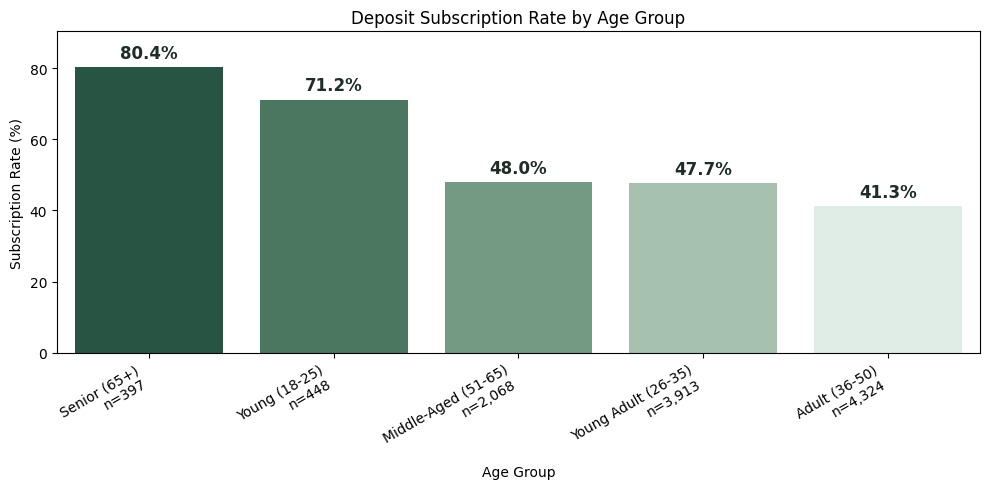

In [226]:
age_order = [
    "Young (18-25)",
    "Young Adult (26-35)",
    "Adult (36-50)",
    "Middle-Aged (51-65)",
    "Senior (65+)"
]

analyze_profile_variable(df, "age_group", sort=True)

Customers aged 60 and over present the highest conversion rate (around 78%), suggesting that older clients are considerably more likely to subscribe to a term depo
sit than younger age groups. This may be related to greater financial stability or more conservative investment preferences, although further analysis would be required to confirm these factors.


### Job profile

Occupational groups are compared to identify whether employment status influences customers' propensity to subscribe.

deposit,non_subscription_rate,subscription_rate,n_clients
job_profile,,,
Student,25.3,74.7,359
Retired,33.7,66.3,777
Unemployed,43.4,56.6,357
Unknown,51.4,48.6,70
White Collar,51.6,48.4,5716
Self-Employed,57.7,42.3,732
Blue Collar,62.2,37.8,3139


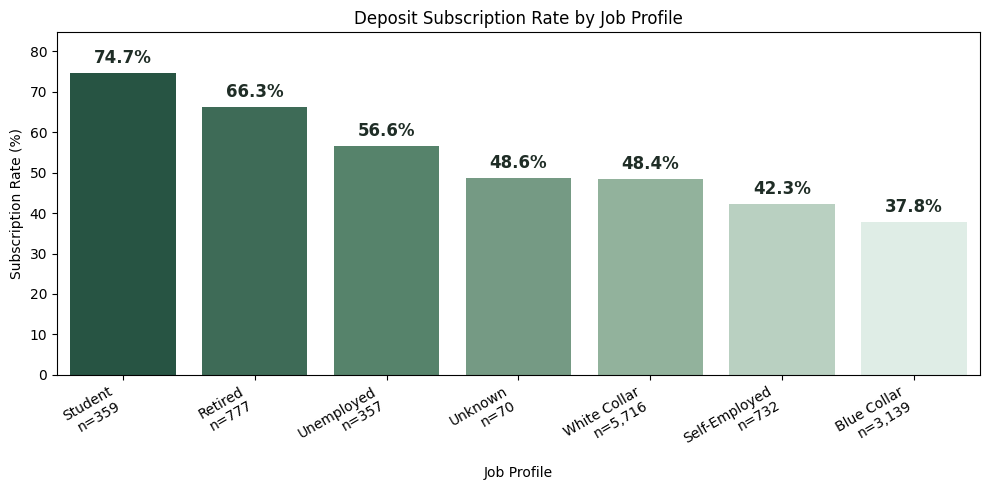

In [227]:
analyze_profile_variable(df, "job_profile", sort=True)

Students and retired customers exhibit the highest subscription rates, while operational occupations show the lowest conversion.
This suggests that employment profile is an important differentiating factor in customer behaviour.

In [228]:
pd.crosstab(
    df["job"],
    df["deposit"],
    normalize="index"
).mul(100).round(1)

deposit,0,1
job,,
admin.,52.7,47.3
blue-collar,63.6,36.4
entrepreneur,62.4,37.6
housemaid,60.2,39.8
management,49.3,50.7
retired,33.7,66.3
self-employed,53.8,46.2
services,60.0,40.0
student,25.3,74.7


### Education

Education level is evaluated as a potential indicator of financial behaviour and product adoption.

deposit,non_subscription_rate,subscription_rate,n_clients
education_label,,,
Tertiary,45.9,54.1,3684
Unknown,49.2,50.8,496
Secondary,55.3,44.7,5472
Primary,60.5,39.5,1498


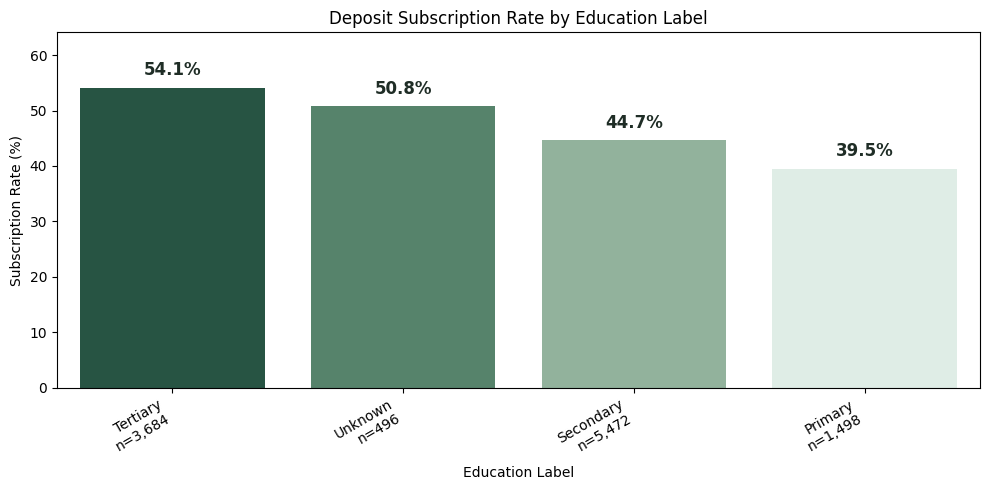

In [229]:
analyze_profile_variable(df, "education_label", sort=True)

Customers with tertiary education consistently achieve the highest subscription rates, whereas secondary education records the lowest conversion. The results suggest a positive association between education level and deposit subscription.

### Marital Status

Marital status is analysed to assess whether customers’ family situation is associated with different subscription rates.

deposit,non_subscription_rate,subscription_rate,n_clients
marital,,,
single,45.7,54.3,3513
divorced,52.0,48.0,1291
married,56.6,43.4,6346


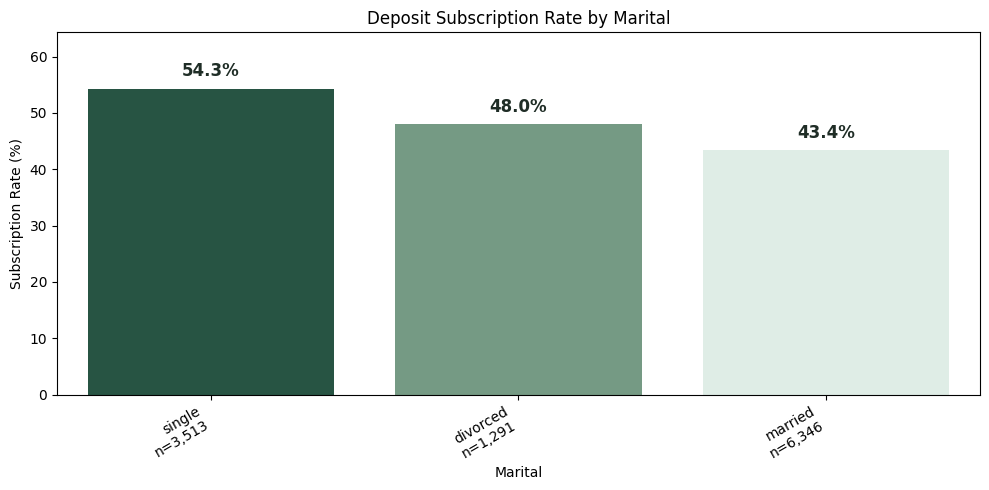

In [230]:
analyze_profile_variable(df, "marital", sort=True)

Single customers show the highest subscription rate, while married customers present the lowest conversion. This suggests that marital status may be associated with different financial priorities and product adoption behaviour.

### Age x Job

Combining demographic variables provides a more detailed customer profile than analysing each characteristic separately. The heatmap highlights the interaction between age and occupation.

In [231]:
summary = (
    df.groupby(["age_group", "job_profile"], observed=True)["deposit"]
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .rename(columns={1: "subscription_rate",
                       0: "non_subscription_rate"})
      .round(1)
)

summary["n_clients"] = (
    df.groupby(["age_group", "job_profile"], observed=True)
      .size()
)

display(summary)

deposit                            non_subscription_rate  subscription_rate  \
age_group           job_profile                                               
Adult (36-50)       Blue Collar                     65.7               34.3   
                    Retired                         75.0               25.0   
                    Self-Employed                   63.2               36.8   
                    Student                         36.4               63.6   
                    Unemployed                      48.8               51.2   
                    Unknown                         58.1               41.9   
                    White Collar                    54.7               45.3   
Middle-Aged (51-65) Blue Collar                     62.9               37.1   
                    Retired                         43.8               56.2   
                    Self-Employed                   60.6               39.4   
                    Unemployed                      38.7               61.3   
                    Unknown                         45.5               54.5   
                    White Collar                    49.7               50.3   
Senior (65+)        Blue Collar                     21.4               78.6   
                    Retired                         19.5               80.5   
                    Self-Employed                    NaN              100.0   
                    Unknown                         50.0               50.0   
                    White Collar                    20.8               79.2   
Young (18-25)       Blue Collar                     36.1               63.9   
                    Self-Employed                   21.4               78.6   
                    Student                         19.7               80.3   
                    Unemployed                      16.7               83.3   
                    White Collar                    36.5               63.5   
Young Adult (26-35) Blue Collar                     60.6               39.4   
                    Retired                         50.0               50.0   
                    Self-Employed                   52.2               47.8   
                    Student                         30.5               69.5   
                    Unemployed                      40.5               59.5   
                    Unknown                         46.2               53.8   
                    White Collar                    50.4               49.6   

deposit                            n_clients  
age_group           job_profile               
Adult (36-50)       Blue Collar         1407  
                    Retired               20  
                    Self-Employed        323  
                    Student               22  
                    Unemployed           160  
                    Unknown               31  
                    White Collar        2361  
Middle-Aged (51-65) Blue Collar          499  
                    Retired              406  
                    Self-Employed        142  
                    Unemployed            75  
                    Unknown               22  
                    White Collar         924  
Senior (65+)        Blue Collar           14  
                    Retired              349  
                    Self-Employed          6  
                    Unknown                4  
                    White Collar          24  
Young (18-25)       Blue Collar          108  
                    Self-Employed         14  
                    Student              183  
                    Unemployed             6  
                    White Collar         137  
Young Adult (26-35) Blue Collar         1111  
                    Retired                2  
                    Self-Employed        247  
                    Student              154  
                    Unemployed           116  
                    Unknown               13  
              

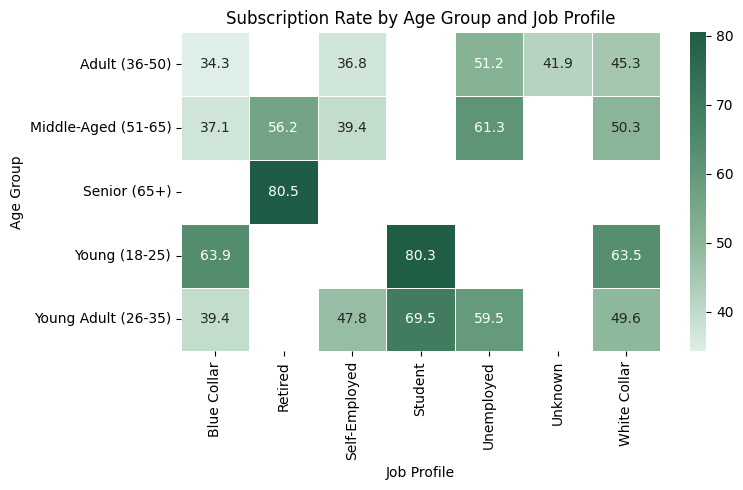

In [232]:
summary_filtered = summary.copy()
summary_filtered.loc[
    summary_filtered["n_clients"] < 30,
    "subscription_rate"
] = np.nan

heatmap_data = summary_filtered["subscription_rate"].unstack()
plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=sns.blend_palette(
        ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"],
        as_cmap=True
    ),
    linewidths=0.5
)

plt.title("Subscription Rate by Age Group and Job Profile")
plt.xlabel("Job Profile")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

Students and retired customers consistently present the highest subscription rates, whereas operational occupations remain the weakest-performing group across most age segments. Results from very small groups should be interpreted cautiously. Cells with missing values represent combinations with insufficient observations and were excluded from interpretation.

### Education × Marital

A second multivariate analysis explores whether education and marital status jointly influence subscription behaviour.

In [233]:
summary = (
    df.groupby(["education_label", "marital"], observed=True)["deposit"]
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .rename(columns={
          1: "subscription_rate",
          0: "non_subscription_rate"
      })
      .round(1)
)

summary["n_clients"] = (
    df.groupby(["education_label", "marital"], observed=True)
      .size()
)

display(summary)

deposit                   non_subscription_rate  subscription_rate  n_clients
education_label marital                                                      
Primary         divorced                   49.0               51.0        204
                married                    63.9               36.1       1097
                single                     53.8               46.2        197
Secondary       divorced                   55.5               44.5        650
                married                    58.2               41.8       3119
                single                     49.9               50.1       1703
Tertiary        divorced                   47.4               52.6        386
                married                    50.5               49.5       1842
                single                     39.7               60.3       1456
Unknown         divorced                   52.9               47.1         51
                married                    50.7               49.3        288
                single                     45.2               54.8        157

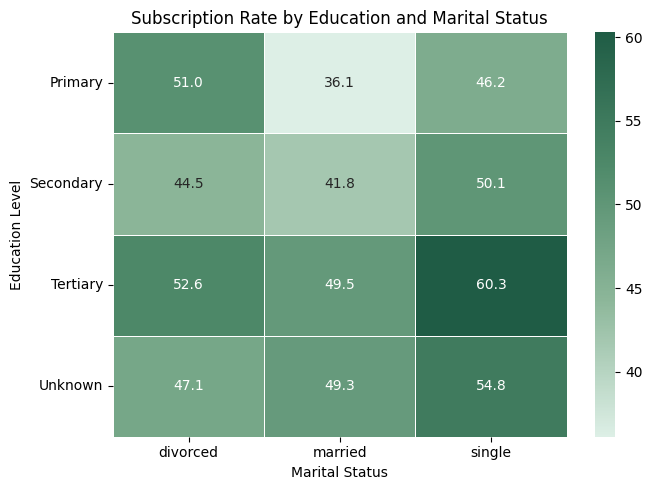

In [234]:
# filter small groups

summary_filtered = summary.copy()

summary_filtered.loc[
    summary_filtered["n_clients"] < 30,
    "subscription_rate"
] = np.nan

# heatmap

heatmap_data = summary_filtered["subscription_rate"].unstack()

# order

education_order = [
    "Primary",
    "Secondary",
    "Tertiary",
    "Unknown"
]

heatmap_data = heatmap_data.reindex(education_order)

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=sns.blend_palette(
        ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"],
        as_cmap=True
    ),
    linewidths=0.5
)

plt.title("Subscription Rate by Education and Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Education Level")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Subscription rates tend to increase with higher education levels, especially among single customers. Married customers with primary or secondary education show the lowest conversion rates, while single customers with tertiary education exhibit the highest subscription rate (62.5%).

## Business Conclusions

### Key findings

Older customers, students and retired clients exhibit the highest subscription rates.
Tertiary education is consistently associated with higher conversion.
Multivariate analysis confirms that demographic characteristics interact, producing customer segments with substantially different subscription behaviour.

The analysis indicates that the most favourable customer profile combines higher education, single marital status, and demographic segments such as students or retirees, which consistently achieve the highest subscription rates across the analyses.

### Business implication

Demographic profiling can support more targeted marketing campaigns by identifying customer segments with the highest likelihood of subscribing to a term deposit.

# Estudio perfiles semana 2
### Distribución segmentos

In [235]:
orden_segmentos = df["segment_label"].value_counts().index

segmentos = (
    df["segment_label"]
    .value_counts()
    .rename_axis("Segmento")
    .reset_index(name="Clientes")
)

segmentos["Porcentaje (%)"] = (
    segmentos["Clientes"] / segmentos["Clientes"].sum() * 100
).round(1)

segmentos["Etiqueta"] = [
    f"{textwrap.fill(str(seg), width=16)}\nn={n:,}".replace(",", ".")
    for seg, n in zip(segmentos["Segmento"], segmentos["Clientes"])
]

display(segmentos)

colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

palette = sns.blend_palette(
    colors,
    n_colors=segmentos.shape[0]
)

,Segmento,Clientes,Porcentaje (%),Etiqueta
0,Trabajadores técnicos,2880,25.8,Trabajadores\ntécnicos\nn=2.880
1,Jovenes en consolidación,2437,21.9,Jovenes en\nconsolidación\nn=2.437
2,Adultos consolidados,2415,21.7,Adultos\nconsolidados\nn=2.415
3,Profesionales estudios superiores,2282,20.5,Profesionales\nestudios\nsuperiores\nn=2.282
4,Jubilados,777,7.0,Jubilados\nn=777
5,Estudiantes,359,3.2,Estudiantes\nn=359


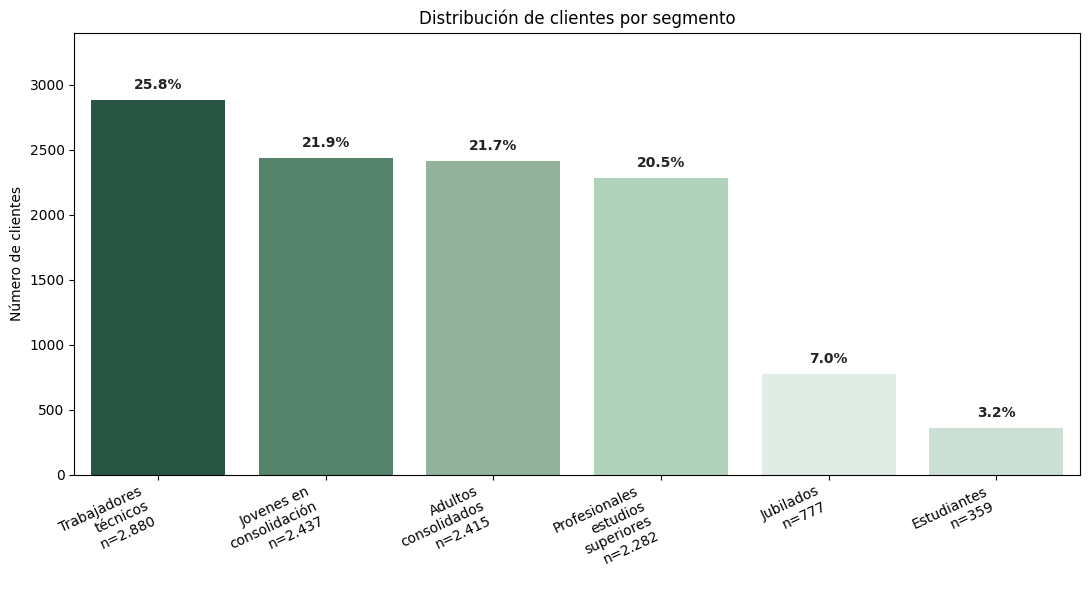

In [236]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=segmentos,
    x="Etiqueta",
    y="Clientes",
    hue="Etiqueta",
    palette=palette,
    legend=False
)

plt.title("Distribución de clientes por segmento")
plt.xlabel("")
plt.ylabel("Número de clientes")
plt.xticks(rotation=25, ha="right")

# Etiquetas encima de las barras
for i, row in segmentos.set_index("Segmento").loc[orden_segmentos].reset_index().iterrows():
    ax.text(
        i,
        row["Clientes"] + 60,
        f'{row["Porcentaje (%)"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )

# Dar espacio arriba para que las etiquetas no se corten
ax.set_ylim(0, segmentos["Clientes"].max() * 1.18)

plt.tight_layout()
plt.show()

La distribución de clientes por segmento muestra cuatro grupos principales con tamaños similares, entre el 20,1 % y el 24,6 % del total. Los segmentos de jubilados y estudiantes son más pequeños, pero se mantienen separados por su comportamiento diferencial observado previamente. Esta distribución permite comparar el comportamiento financiero entre perfiles sin que un único segmento domine el análisis.

### Analisis variables financieras

In [237]:
# función reutilizable numeric


def format_segment_label(segment, n=None):
    label = SEGMENT_LABEL_MAP.get(str(segment), str(segment))

    if n is not None:
        label = f"{label}\nn={n:,}".replace(",", ".")

    return label

def format_segment_label(segment, n=None):
    label = SEGMENT_LABEL_MAP.get(str(segment), str(segment))

    if n is not None:
        label = f"{label}\nn={n:,}".replace(",", ".")

    return label

def analyze_numeric_by_segment(df, variable, segment_col="segment_label"):
    """
    Analiza una variable numérica por segmento.
    Genera una tabla resumen y un gráfico de barras con la mediana.
    """

    summary = (
        df.groupby(segment_col, observed=True)[variable]
          .agg(
              n_clients="count",
              mean="mean",
              median="median",
              std="std",
              min="min",
              max="max"
          )
          .round(2)
          .sort_values("median", ascending=False)
    )

    display(summary)

    # Código anterior:
    # summary["label"] = [
    #     f"{textwrap.fill(str(segment), width=16)}\nn={n:,}".replace(",", ".")
    #     for segment, n in zip(summary.index, summary["n_clients"])
    # ]

    segment_label_map = {
        "Adultos consolidados": "Consolidados",
        "Estudiantes": "Estudiantes",
        "Jovenes en consolidación": "Jóvenes",
        "Jóvenes en consolidación": "Jóvenes",
        "Jubilados": "Jubilados",
        "Profesionales estudios superiores": "Profesionales",
        "Trabajadores técnicos": "Técnicos",
    }

    summary["label"] = [
        f"{segment_label_map.get(str(segment).strip(), str(segment).strip())}\nn={n:,}".replace(",", ".")
        for segment, n in zip(summary.index, summary["n_clients"])
    ]

    colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

    palette = sns.blend_palette(
        colors,
        n_colors=summary.shape[0]
    )

    plot_data = summary.reset_index()

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=plot_data,
        x="label",
        y="median",
        hue="label",
        palette=palette,
        legend=False,
        width=0.8,
        dodge=False
    )

    for index, row in plot_data.iterrows():
        ax.text(
            x=index,
            y=row["median"] + (plot_data["median"].max() * 0.03),
            s=f'{row["median"]:,.0f} €'.replace(",", "."),
            ha="center",
            va="bottom",
            fontsize=12,
            color="#1F2D26",
            fontweight="bold"
        )

    #plt.title(f"Mediana de {variable.replace('_', ' ').title()} por segmento")
    plt.xlabel("Segmento")
    plt.ylabel(f"Mediana de {variable}")
    plt.xticks(rotation=45, ha="right")

    plt.ylim(0, plot_data["median"].max() * 1.18)

    plt.tight_layout()
    plt.show()

In [238]:
# función reutilizable categoric


def format_segment_label(segment, n=None):
    label = SEGMENT_LABEL_MAP.get(str(segment), str(segment))

    if n is not None:
        label = f"{label}\nn={n:,}".replace(",", ".")

    return label

def analyze_categorical_by_segment(
    df,
    variable,
    segment_col="segment_label",
    order=None,
    highlight_value="yes",
    sort_by_highlight=True,
    x_limit=None
):
    counts = pd.crosstab(df[segment_col], df[variable])

    percentages = (
        pd.crosstab(df[segment_col], df[variable], normalize="index")
        .mul(100)
        .round(1)
    )

    if order is not None:
        counts = counts.reindex(columns=order, fill_value=0)
        percentages = percentages.reindex(columns=order, fill_value=0)

    if highlight_value not in percentages.columns:
        raise ValueError(
            f"'{highlight_value}' is not present in {variable}. "
            f"Available values: {list(percentages.columns)}"
        )

    segment_n = counts.sum(axis=1)

    summary = percentages.copy()
    summary["n_clients"] = segment_n

    display(summary)

    plot_data = pd.DataFrame({
        "segment": percentages.index,
        "highlight_rate": percentages[highlight_value],
        "n_clients": segment_n
    })

    # Previous automatic wrapping version:
    # plot_data["label"] = [
    #     f"{textwrap.fill(str(segment), width=16)}\nn={n:,}".replace(",", ".")
    #     for segment, n in zip(plot_data["segment"], plot_data["n_clients"])
    # ]

    segment_label_map = {
        "Profesionales estudios superiores": "Profesionales\nestudios superiores",
        "Jovenes en consolidación": "Jóvenes en\nconsolidación",
        "Jóvenes en consolidación": "Jóvenes en\nconsolidación",
        "Trabajadores técnicos": "Trabajadores\ntécnicos",
        "Adultos consolidados": "Adultos\nconsolidados",
    }

    plot_data["label"] = [
        f"{segment_label_map.get(segment, str(segment))}\nn={n:,}".replace(",", ".")
        for segment, n in zip(plot_data["segment"], plot_data["n_clients"])
    ]

    if sort_by_highlight:
        plot_data = plot_data.sort_values(
            by="highlight_rate",
            ascending=False
        )

    label_order = plot_data["label"].tolist()

    fig_height = max(4.5, 0.65 * len(plot_data))

    plt.figure(figsize=(10, fig_height))

    ax = sns.barplot(
        data=plot_data,
        x="highlight_rate",
        y="label",
        order=label_order,
        color="#4F8A6A"
    )

    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2

        ax.text(
            x=width + 0.6,
            y=y,
            s=f"{width:.1f}%",
            va="center",
            ha="left",
            fontsize=12,
            fontweight="bold",
            color="#1F2D26"
        )

    max_rate = plot_data["highlight_rate"].max()

    if x_limit is None:
        x_limit = min(100, max_rate + 8)

    plt.xlim(0, x_limit)

    highlight_label = str(highlight_value).replace("_", " ").title()
    variable_label = variable.replace("_", " ").title()

    plt.title(f"{highlight_label} Rate in {variable_label} by Segment")
    plt.xlabel("Percentage (%)")
    plt.ylabel("Segment")

    ax.grid(False)
    sns.despine(left=True, bottom=False)

    plt.tight_layout()
    plt.show()

#### Balance

,n_clients,mean,median,std,min,max
segment_label,,,,,,
Jubilados,777,2414.97,1084.0,5402.38,-1206,81204
Adultos consolidados,2415,1845.17,665.0,3801.00,-6847,66653
Profesionales estudios superiores,2282,1591.21,576.0,3122.65,-3058,45248
Estudiantes,359,1503.90,493.0,2661.40,0,23878
Jovenes en consolidación,2437,1229.71,463.0,2431.43,-1701,56831
Trabajadores técnicos,2880,1233.88,454.0,2504.09,-1139,36252


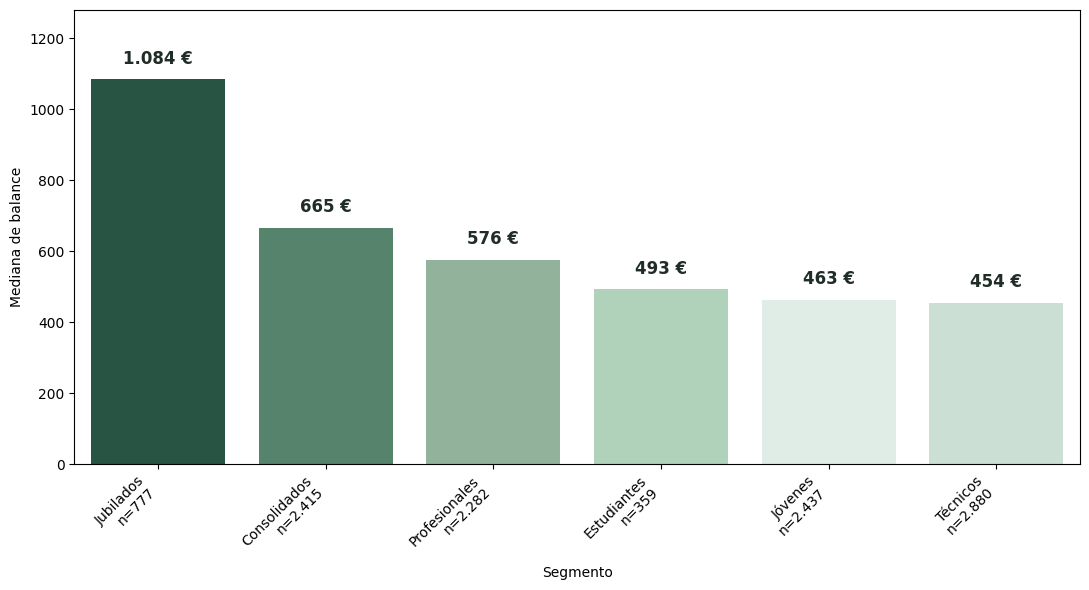

In [239]:
analyze_numeric_by_segment(df, "balance")

Los jubilados presentan la mayor mediana de saldo, mientras que los jóvenes solteros y los trabajadores manuales muestran los niveles más bajos. La diferencia entre medias y medianas confirma una fuerte asimetría provocada por un número reducido de clientes con saldos muy elevados.

#### Housing

housing,no,yes,n_clients
segment_label,,,
Adultos consolidados,61.7,38.3,2415
Estudiantes,85.8,14.2,359
Jovenes en consolidación,36.7,63.3,2437
Jubilados,84.2,15.8,777
Profesionales estudios superiores,51.4,48.6,2282
Trabajadores técnicos,46.9,53.1,2880


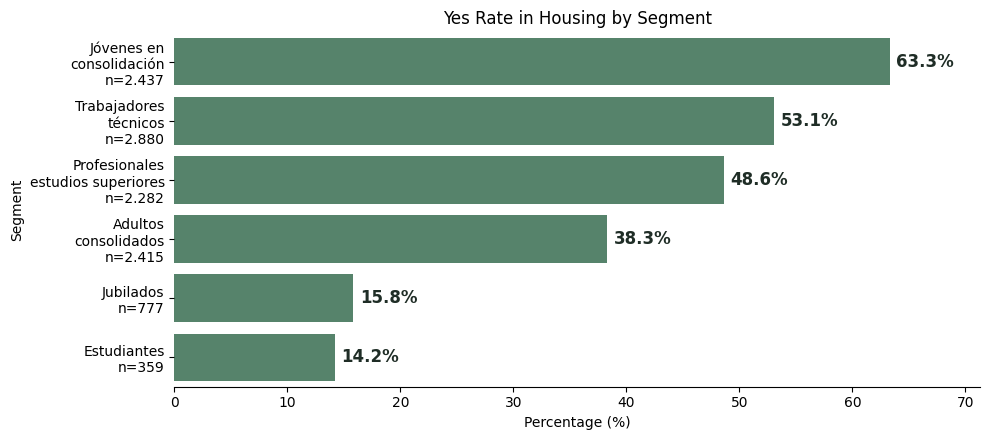

In [240]:
analyze_categorical_by_segment(df, "housing", order=["no", "yes"], highlight_value="yes")

Los trabajadores manuales son el segmento con mayor proporción de hipotecas, seguidos por los jóvenes solteros. En cambio, estudiantes y jubilados apenas presentan financiación hipotecaria, lo que refleja perfiles financieros claramente diferenciados.

#### Loan

loan,no,yes,n_clients
segment_label,,,
Adultos consolidados,86.0,14.0,2415
Estudiantes,99.7,0.3,359
Jovenes en consolidación,83.5,16.5,2437
Jubilados,92.9,7.1,777
Profesionales estudios superiores,88.1,11.9,2282
Trabajadores técnicos,86.5,13.5,2880


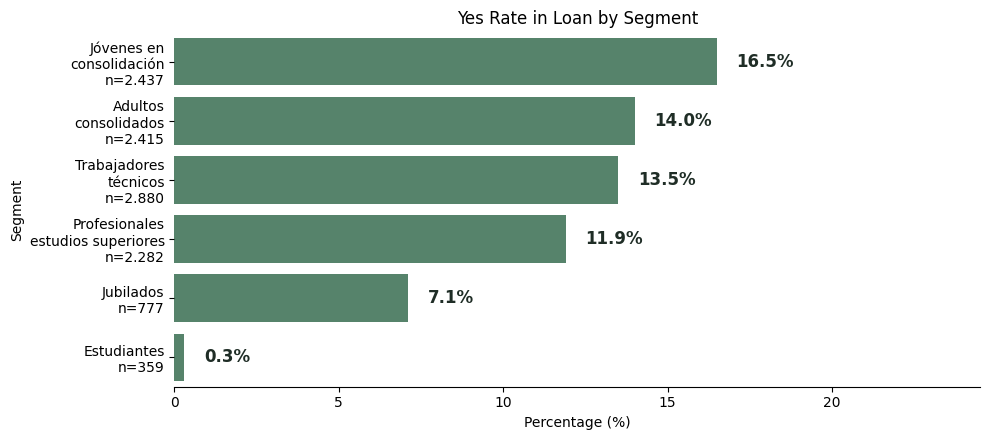

In [241]:
analyze_categorical_by_segment(df, "loan", order=["no", "yes"], highlight_value="yes")

El préstamo personal es poco frecuente en todos los segmentos. Los trabajadores manuales concentran la mayor proporción de clientes con este producto, mientras que los estudiantes prácticamente no recurren a este tipo de financiación.

### Préstamo VS Hipoteca

In [242]:
def plot_housing_loan_by_segment(
    df,
    segment_col="segment_label",
    sort_by="housing",
    yes_value="yes"
):
    """
    Compara el porcentaje de clientes con hipoteca y préstamo personal
    por segmento mediante barras agrupadas verticales.
    """

    segment_n = df[segment_col].value_counts()

    housing_rate = (
        pd.crosstab(df[segment_col], df["housing"], normalize="index")
        .mul(100)
        .round(1)
    )

    loan_rate = (
        pd.crosstab(df[segment_col], df["loan"], normalize="index")
        .mul(100)
        .round(1)
    )

    summary = pd.DataFrame({
        "housing_yes_rate": housing_rate.get(yes_value, 0),
        "loan_yes_rate": loan_rate.get(yes_value, 0),
        "n_clients": segment_n
    })

    if sort_by == "housing":
        summary = summary.sort_values("housing_yes_rate", ascending=False)
    elif sort_by == "loan":
        summary = summary.sort_values("loan_yes_rate", ascending=False)
    elif sort_by == "average":
        summary["average_rate"] = (
            summary["housing_yes_rate"] + summary["loan_yes_rate"]
        ) / 2
        summary = summary.sort_values("average_rate", ascending=False)

    display(summary)

    plot_data = summary.reset_index().rename(columns={segment_col: "segment"})

    # Código anterior:
    # plot_data["label"] = [
    #     f"{textwrap.fill(str(segment), width=16)}\nn={n:,}".replace(",", ".")
    #     for segment, n in zip(plot_data["segment"], plot_data["n_clients"])
    # ]

    segment_label_map = {
    "Adultos consolidados": "Consolidados",
    "Estudiantes": "Estudiantes",
    "Jovenes en consolidación": "Jóvenes",
    "Jóvenes en consolidación": "Jóvenes",
    "Jubilados": "Jubilados",
    "Profesionales estudios superiores": "Profesionales",
    "Trabajadores técnicos": "Técnicos",
}

    plot_data["label"] = [
        f"{segment_label_map.get(str(segment), str(segment))}\nn={n:,}".replace(",", ".")
        for segment, n in zip(plot_data["segment"], plot_data["n_clients"])
    ]

    plot_data_long = plot_data.melt(
        id_vars=["segment", "label", "n_clients"],
        value_vars=["housing_yes_rate", "loan_yes_rate"],
        var_name="financial_product",
        value_name="percentage"
    )

    product_labels = {
        "housing_yes_rate": "Hipoteca",
        "loan_yes_rate": "Préstamo personal"
    }

    plot_data_long["financial_product"] = (
        plot_data_long["financial_product"].map(product_labels)
    )

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=plot_data_long,
        x="label",
        y="percentage",
        hue="financial_product",
        palette=["#1F5C45", "#8DB79A"]
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=12,
            fontweight="bold",
            color="#1F2D26"
        )

    max_value = plot_data_long["percentage"].max()
    plt.ylim(0, min(100, max_value + 10))

    # plt.title("Hipoteca y préstamo personal por segmento")
    plt.xlabel("Segmento")
    plt.ylabel("Clientes con producto (%)")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Producto financiero")

    ax.grid(False)
    sns.despine(left=False, bottom=False)

    plt.tight_layout()
    plt.show()

,housing_yes_rate,loan_yes_rate,n_clients
segment_label,,,
Jovenes en consolidación,63.3,16.5,2437
Trabajadores técnicos,53.1,13.5,2880
Profesionales estudios superiores,48.6,11.9,2282
Adultos consolidados,38.3,14.0,2415
Jubilados,15.8,7.1,777
Estudiantes,14.2,0.3,359


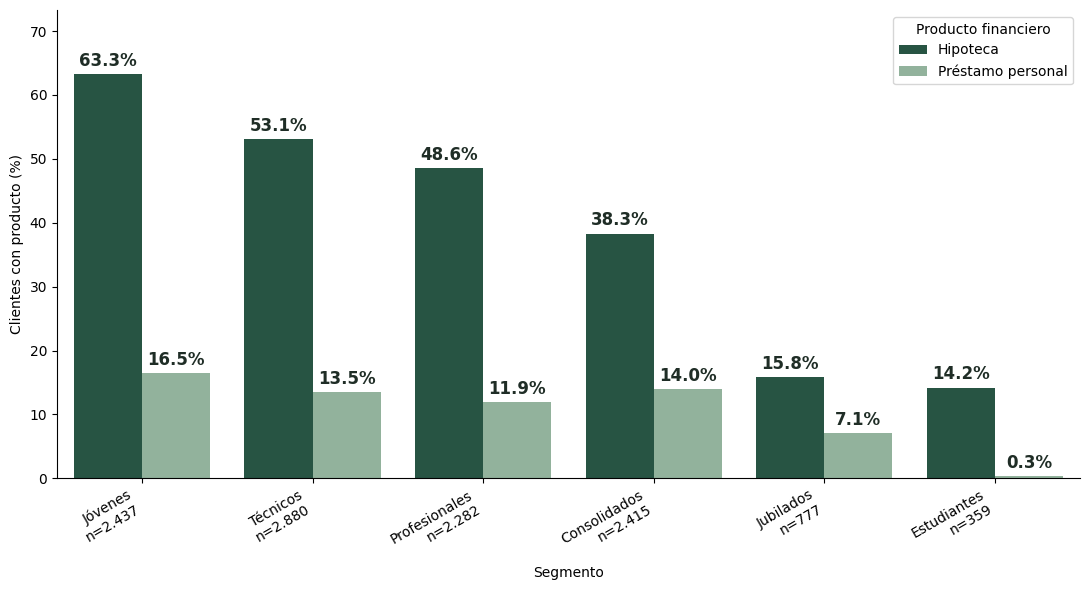

In [243]:
plot_housing_loan_by_segment(df)

#### Engagement

vinculacion,0,1,2,3,n_clients
segment_label,,,,,
Adultos consolidados,23.9,56.3,17.8,2.1,2415
Estudiantes,17.0,76.9,6.1,0.0,359
Jovenes en consolidación,17.4,52.6,27.2,2.8,2437
Jubilados,21.9,68.3,8.5,1.3,777
Profesionales estudios superiores,19.6,55.3,22.6,2.5,2282
Trabajadores técnicos,15.3,55.5,26.4,2.8,2880


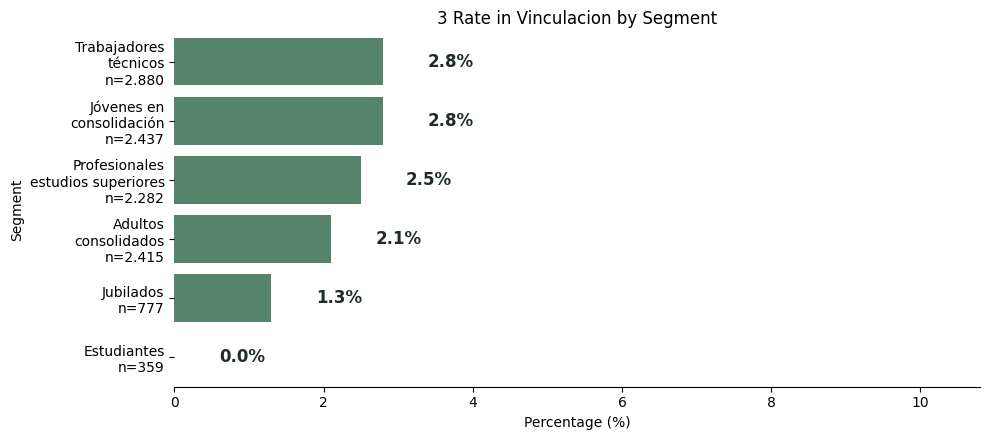

In [244]:
analyze_categorical_by_segment(df, "vinculacion", highlight_value= 3)

La carga financiera varía notablemente entre segmentos. Los trabajadores manuales presentan la mayor proporción de clientes con carga financiera alta o moderada, mientras que jubilados y estudiantes se concentran principalmente en situaciones de baja o nula carga financiera.

nueva conclusion:
El nivel de engagement varía notablemente entre segmentos. Los trabajadores técnicos presentan la mayor proporción de clientes con alto engagement (11,7%), seguidos de un bloque intermedio bastante homogéneo (profesionales con estudios superiores, jóvenes en consolidación y adultos consolidados, entre el 6,8% y el 7,2%). Jubilados (2,9%) y, especialmente, estudiantes (0,0%) presentan los niveles de engagement más bajos, lo que indica que apenas tienen productos de crédito contratados con la entidad más allá de la cuenta base.

Esta variable debe interpretarse en sentido opuesto a como se interpretaba bajo el concepto anterior de "carga financiera": un alto engagement no representa un riesgo, sino un vínculo comercial más profundo con el cliente. Bajo esta óptica, jubilados y estudiantes no son segmentos "sanos" por tener poca exposición, sino segmentos con mayor margen de venta cruzada, ya que actualmente mantienen muy pocos productos contratados.

#### Default

default,no,yes,n_clients
segment_label,,,
Adultos consolidados,98.5,1.5,2415
Estudiantes,99.7,0.3,359
Jovenes en consolidación,98.0,2.0,2437
Jubilados,99.4,0.6,777
Profesionales estudios superiores,98.8,1.2,2282
Trabajadores técnicos,98.3,1.7,2880


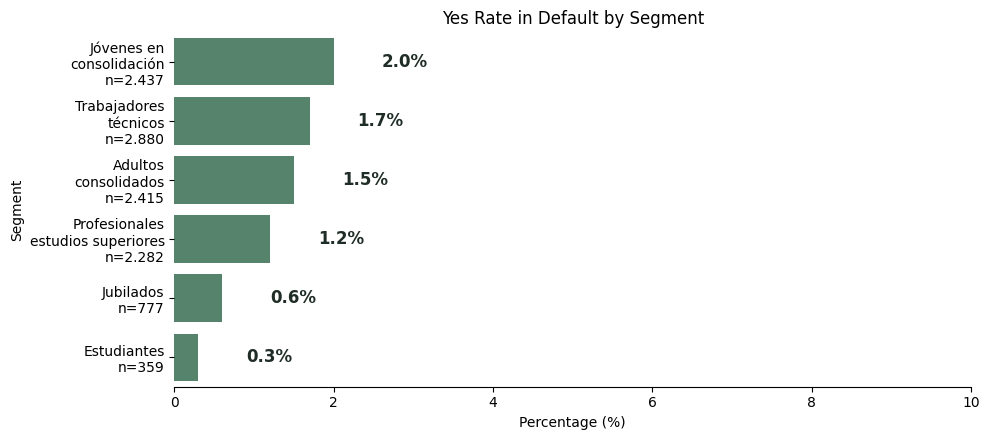

In [245]:
analyze_categorical_by_segment(df, "default", order=["no", "yes"], highlight_value="yes")

El porcentaje de clientes en situación de impago es muy reducido en todos los segmentos y las diferencias observadas son mínimas. Esta variable no parece aportar capacidad de diferenciación entre los perfiles demográficos identificados.

### Resumen del perfil financiero por segmento

In [246]:
perfil = (
    df.groupby("segment_label", observed=True)
      .agg(
          Clientes=("id", "count"),
          Balance_mediana=("balance", "median"),
          Hipoteca_pct=("housing", lambda x: (x == "yes").mean() * 100),
          Prestamo_personal_pct=("loan", lambda x: (x == "yes").mean() * 100),
          Engagement_alto_pct=("vinculacion", lambda x: (x == 3).mean() * 100),
          Engagement_bajo_pct=("vinculacion", lambda x: (x == 1).mean() * 100),
          Default_pct=("default", lambda x: (x == "yes").mean() * 100)
      )
      .round(1)
)

perfil = perfil.rename(columns={
    "Balance_mediana": "Mediana balance (€)",
    "Hipoteca_pct": "Hipoteca (%)",
    "Prestamo_personal_pct": "Préstamo personal (%)",
    "Engagement_alto_pct": "Engagement alto (%)",
    "Engagement_bajo_pct": "Engagement bajo (%)",
    "Default_pct": "Default (%)"
})

display(perfil)

,Clientes,Mediana balance (€),Hipoteca (%),Préstamo personal (%),Engagement alto (%),Engagement bajo (%),Default (%)
segment_label,,,,,,,
Adultos consolidados,2415,665.0,38.3,14.0,2.1,56.3,1.5
Estudiantes,359,493.0,14.2,0.3,0.0,76.9,0.3
Jovenes en consolidación,2437,463.0,63.3,16.5,2.8,52.6,2.0
Jubilados,777,1084.0,15.8,7.1,1.3,68.3,0.6
Profesionales estudios superiores,2282,576.0,48.6,11.9,2.5,55.3,1.2
Trabajadores técnicos,2880,454.0,53.1,13.5,2.8,55.5,1.7


- Jubilados presentan el perfil financiero más sólido: tienen la mediana de balance más alta y bajos niveles de endeudamiento (hipoteca, préstamo personal y carga financiera alta)
- Trabajadores manuales muestran la mayor exposición financiera del conjunto. Son el segmento con mayor porcentaje de hipotecas, préstamos personales y carga financiera alta, además de presentar el balance mediano más bajo
- Profesionales con estudios superiores mantienen un balance relativamente elevado, aunque una proporción importante dispone de hipoteca. Su nivel de carga financiera se sitúa en valores intermedios
- Adultos consolidados presentan un perfil equilibrado, con un balance superior a la media de la mayoría de segmentos y niveles moderados de financiación
- Jóvenes solteros poseen el menor patrimonio (mediana de balance) pero una elevada presencia de hipotecas, lo que sugiere una etapa inicial de consolidación financiera
- Estudiantes destacan por una exposición financiera prácticamente nula: muy pocos tienen hipoteca o préstamo personal y no se observan casos con carga financiera alta
- Default registra valores muy bajos en todos los segmentos (inferiores al 2 %), por lo que no parece ser una variable que diferencie claramente los perfiles financieros


nueva interpretacion:
El nivel de engagement varía notablemente entre segmentos, y la lectura es opuesta según el extremo de la distribución que se observe:

- **Trabajadores técnicos** presenta el mayor engagement alto (11,7%) y el menor engagement bajo (28,4%) — es el segmento más vinculado a la entidad en términos de productos contratados.
- **Estudiantes** (85,5% bajo engagement) y **Jubilados** (80,2% bajo engagement) son los segmentos con menor vinculación actual, lo que representa el mayor margen de oportunidad para venta cruzada, no un signo de solidez financiera per se.
- El resto de segmentos (Adultos consolidados, Jóvenes en consolidación, Profesionales con estudios superiores) se sitúan en una franja intermedia, con engagement bajo entre el 42% y el 53%.

A diferencia del enfoque anterior (carga financiera), donde un valor alto era una señal de alerta, aquí un valor alto de engagement indica una relación comercial más profunda con el cliente. El foco de negocio se desplaza: en lugar de identificar segmentos "en riesgo", el objetivo es identificar segmentos con margen de crecimiento (bajo engagement) sobre los que dirigir estrategias de vinculación.

In [247]:
df.groupby(["segment_label", "vinculacion"])["balance"].agg(
    clients="count",
    median_balance="median",
    mean_balance="mean"
).round(1)

clients  median_balance  \
segment_label                     vinculacion                            
Adultos consolidados              0                576           524.5   
                                  1               1360           757.0   
                                  2                429           765.0   
                                  3                 50           356.0   
Estudiantes                       0                 61           468.0   
                                  1                276           497.5   
                                  2                 22           725.5   
Jovenes en consolidación          0                424           415.0   
                                  1               1282           450.5   
                                  2                663           523.0   
                                  3                 68           232.5   
Jubilados                         0                170           868.5   
                                  1                531          1129.0   
                                  2                 66          1158.0   
                                  3                 10          1577.5   
Profesionales estudios superiores 0                448           472.0   
                                  1               1262           606.0   
                                  2                516           551.0   
                                  3                 56           461.5   
Trabajadores técnicos             0                440           336.0   
                                  1               1598           521.5   
                                  2                761           419.0   
                                  3                 81           152.0   

                                               mean_balance  
segment_label                     vinculacion                
Adultos consolidados              0                  1792.0  
                                  1                  1950.6  
                                  2                  1708.3  
                                  3                   764.7  
Estudiantes                       0                  1610.3  
                                  1                  1452.3  
                                  2                  1856.0  
Jovenes en consolidación          0                  1481.5  
                                  1                  1230.1  
                                  2                  1120.5  
                                  3                   716.4  
Jubilados                         0                  2167.3  
                                  1                  2503.1  
                                  2                  2460.5  
                                  3                  1645.7  
Profesionales estudios superiores 0                  1466.3  
                                  1                  1704.3  
                                  2                  1483.7  
                                  3                  1033.1  
Trabajadores técnicos             0                  1223.1  
                                  1                  1328.7  
                                  2                  1125.5  
                                  3                   441.5

La carga financiera parece asociarse con menor liquidez en casi todos los segmentos. Esto ayuda a personalizar ofertas (jóvenes solteros / treballadors manuals con alta carga financiera tienen una mediana de balance muy baja. Perfil tensionado?)

nuevo:
Dentro de cada segmento, el engagement bajo se asocia sistemáticamente con una mediana de balance más alta, y el engagement alto con balances más bajos. Este patrón es coherente con la lógica de vinculación: los clientes con más productos de crédito contratados (mayor engagement) destinan una parte de su liquidez a esos compromisos, mientras que los de bajo engagement conservan más saldo disponible.

Esto ayuda a personalizar ofertas: los segmentos con bajo engagement y alta liquidez (como jubilados y estudiantes) son los mejores candidatos para productos de ahorro o vinculación inicial, mientras que los de alto engagement ya mantienen una relación comercial más profunda y podrían orientarse hacia productos de optimización o consolidación de lo ya contratado.

### Crosstab préstamo / hipoteca

In [248]:
pd.crosstab(
    df["segment_label"],
    [df["housing"], df["loan"]],
    normalize="index"
).mul(100).round(1)

housing                              no        yes      
loan                                 no  yes    no   yes
segment_label                                           
Adultos consolidados               54.5  7.2  31.6   6.7
Estudiantes                        85.5  0.3  14.2   0.0
Jovenes en consolidación           31.0  5.7  52.6  10.8
Jubilados                          80.1  4.1  12.9   3.0
Profesionales estudios superiores  47.1  4.3  41.0   7.6
Trabajadores técnicos              40.8  6.1  45.6   7.4

In [249]:
def plot_combinacion_credito_por_segmento(df, segment_col="segment_label"):
    """
    Muestra la distribución de combinaciones de hipoteca y préstamo personal
    por segmento mediante barras verticales 100% apiladas.
    """

    tabla_combinacion = (
        pd.crosstab(
            df[segment_col],
            [df["housing"], df["loan"]],
            normalize="index"
        )
        .mul(100)
        .round(1)
    )

    tabla_combinacion.columns = [
    "Sin hipoteca\nsin préstamo",
    "Sin hipoteca\ncon préstamo",
    "Con hipoteca\nsin préstamo",
    "Con hipoteca\ncon préstamo"
    ]

    segment_n = df[segment_col].value_counts()

    tabla_combinacion["Clientes"] = segment_n

    display(tabla_combinacion)

    orden_columnas = [
        "Con hipoteca\ncon préstamo",
        "Con hipoteca\nsin préstamo",
        "Sin hipoteca\ncon préstamo",
        "Sin hipoteca\nsin préstamo"
    ]

    plot_data = tabla_combinacion[orden_columnas]

    segment_label_map = {
        "Adultos consolidados": "Consolidados",
        "Estudiantes": "Estudiantes",
        "Jovenes en consolidación": "Jóvenes",
        "Jóvenes en consolidación": "Jóvenes",
        "Jubilados": "Jubilados",
        "Profesionales estudios superiores": "Profesionales",
        "Trabajadores técnicos": "Técnicos",
    }

    etiquetas_segmento = [
        f"{segment_label_map.get(str(segmento), str(segmento))}\nn={segment_n[segmento]:,}".replace(",", ".")
        for segmento in plot_data.index
    ]

    colores = ["#1F5C45", "#4F8A6A", "#AAD7B8", "#DDEFE6"]

    ax = plot_data.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6),
        color=colores,
        width=0.75
    )

    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            height = bar.get_height()
            value = height

            if value >= 8:
                face_color = bar.get_facecolor()

                brightness = (
                    0.299 * face_color[0]
                    + 0.587 * face_color[1]
                    + 0.114 * face_color[2]
                )

                text_color = "#F7F7F2" if brightness < 0.55 else "#1F2D26"

                ax.text(
                    x=bar.get_x() + width / 2,
                    y=bar.get_y() + height / 2,
                    s=f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=12,
                    fontweight="bold",
                    color=text_color
                )

    ax.set_xticklabels(etiquetas_segmento, rotation=35, ha="right")

    # plt.title("Combinación de hipoteca y préstamo personal por segmento")
    plt.xlabel("Segmento")
    plt.ylabel("Porcentaje de clientes (%)")
    plt.ylim(0, 100)

    plt.legend(
        title="Combinación de crédito",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(False)
    sns.despine(left=False, bottom=False)

    plt.tight_layout()
    plt.show()

,Sin hipoteca\nsin préstamo,Sin hipoteca\ncon préstamo,Con hipoteca\nsin préstamo,Con hipoteca\ncon préstamo,Clientes
segment_label,,,,,
Adultos consolidados,54.5,7.2,31.6,6.7,2415
Estudiantes,85.5,0.3,14.2,0.0,359
Jovenes en consolidación,31.0,5.7,52.6,10.8,2437
Jubilados,80.1,4.1,12.9,3.0,777
Profesionales estudios superiores,47.1,4.3,41.0,7.6,2282
Trabajadores técnicos,40.8,6.1,45.6,7.4,2880


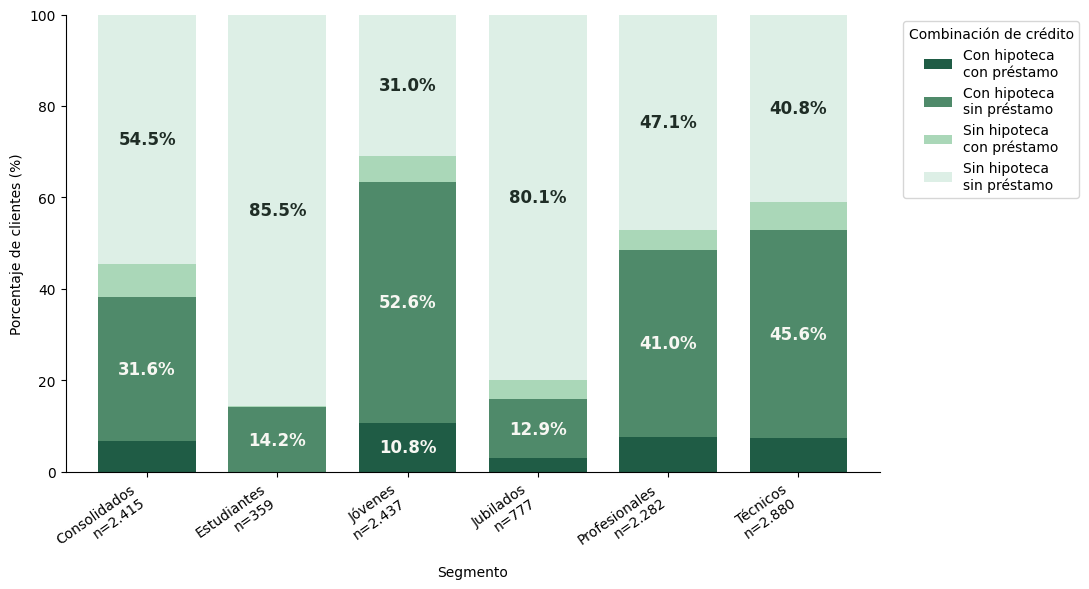

In [250]:
plot_combinacion_credito_por_segmento(df)

11,7% de trabajadores manuales tienen simultáneamente hipoteca y préstamo personal. Es el porcentaje más alto de todos los segmentos. Joves solters 6.9 yes/yes y mediana de deposito baja.

Los perfiles con alta liquidez y baja carga pueden recibir ofertas de ahorro o inversión, mientras que perfiles con baja liquidez y alta exposición deberían recibir propuestas más prudentes

nuevo:
El 11,7% de trabajadores técnicos tiene simultáneamente hipoteca y préstamo personal — el porcentaje más alto de todos los segmentos, coherente con ser el segmento de mayor engagement. Jóvenes en consolidación presenta un 6,9% con ambos productos, combinado con una mediana de balance baja.

Los perfiles con alta liquidez y bajo engagement (jubilados, estudiantes) son los mejores candidatos para ofertas de ahorro, inversión o vinculación inicial, mientras que los de alto engagement (trabajadores técnicos) ya mantienen una relación comercial consolidada y encajan mejor con productos de fidelización u optimización de lo ya contratado, en lugar de nueva financiación.

## Validación estadistica variables categóricas
- Chi-cuadrado (housing)
- Chi-cuadrado (loan)
- Chi-cuadrado (engagement)
- Chi-cuadrado (default)

In [251]:
def chi_cuadrado_por_segmento(df, variable, segmento="segment_label"):
    """
    Aplica la prueba de chi-cuadrado entre una variable categórica
    y los segmentos de clientes.
    """

    tabla = pd.crosstab(df[segmento], df[variable])

    chi2, p_value, dof, expected = chi2_contingency(tabla)

    expected_df = pd.DataFrame(
        expected,
        index=tabla.index,
        columns=tabla.columns
    ).round(2)

    print(f"Variable analizada: {variable}")
    print(f"Chi-cuadrado: {chi2:.4f}")
    print(f"p-value: {p_value:.5f}")
    print(f"Grados de libertad: {dof}")

    print("\nTabla de contingencia")
    display(tabla)

    print("\nFrecuencias esperadas")
    display(expected_df)

    if (expected_df < 5).any().any():
        print("\nAtención: hay frecuencias esperadas menores que 5. El resultado debe interpretarse con cautela.")
    else:
        print("\nSupuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.")

    if p_value < 0.05:
        print("Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.")
    else:
        print("Conclusión: no se observa una asociación estadísticamente significativa entre la variable y el segmento.")

    print("-" * 80)

In [252]:
# Housing

chi_cuadrado_por_segmento(df, "housing")

Variable analizada: housing
Chi-cuadrado: 835.3584
p-value: 0.00000
Grados de libertad: 5

Tabla de contingencia


housing,no,yes
segment_label,,
Adultos consolidados,1490,925
Estudiantes,308,51
Jovenes en consolidación,894,1543
Jubilados,654,123
Profesionales estudios superiores,1173,1109
Trabajadores técnicos,1352,1528



Frecuencias esperadas


housing,no,yes
segment_label,,
Adultos consolidados,1271.61,1143.39
Estudiantes,189.03,169.97
Jovenes en consolidación,1283.20,1153.80
Jubilados,409.13,367.87
Profesionales estudios superiores,1201.58,1080.42
Trabajadores técnicos,1516.46,1363.54



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


Existe una asociación muy fuerte entre el segmento demográfico y la posesión de hipoteca. Algunos segmentos presentan una proporción de hipotecas muy superior a la esperada, mientras que otros se sitúan claramente por debajo, indicando que esta variable diferencia bien los perfiles de clientes.

In [253]:
# Loan

chi_cuadrado_por_segmento(df, "loan")

Variable analizada: loan
Chi-cuadrado: 105.7864
p-value: 0.00000
Grados de libertad: 5

Tabla de contingencia


loan,no,yes
segment_label,,
Adultos consolidados,2078,337
Estudiantes,358,1
Jovenes en consolidación,2036,401
Jubilados,722,55
Profesionales estudios superiores,2010,272
Trabajadores técnicos,2490,390



Frecuencias esperadas


loan,no,yes
segment_label,,
Adultos consolidados,2099.64,315.36
Estudiantes,312.12,46.88
Jovenes en consolidación,2118.77,318.23
Jubilados,675.54,101.46
Profesionales estudios superiores,1984.01,297.99
Trabajadores técnicos,2503.92,376.08



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


Asociación significativa entre el segmento y la contratación de préstamos personales. Aunque las diferencias son menores que en el caso de las hipotecas, determinados segmentos muestran una mayor predisposición a disponer de este producto financiero.

# Engagement


In [254]:

chi_cuadrado_por_segmento(df, "vinculacion")

Variable analizada: vinculacion
Chi-cuadrado: 310.4850
p-value: 0.00000
Grados de libertad: 15

Tabla de contingencia


vinculacion,0,1,2,3
segment_label,,,,
Adultos consolidados,576,1360,429,50
Estudiantes,61,276,22,0
Jovenes en consolidación,424,1282,663,68
Jubilados,170,531,66,10
Profesionales estudios superiores,448,1262,516,56
Trabajadores técnicos,440,1598,761,81



Frecuencias esperadas


vinculacion,0,1,2,3
segment_label,,,,
Adultos consolidados,458.96,1366.48,532.17,57.40
Estudiantes,68.23,203.13,79.11,8.53
Jovenes en consolidación,463.14,1378.93,537.01,57.92
Jubilados,147.66,439.65,171.22,18.47
Profesionales estudios superiores,433.68,1291.22,502.86,54.24
Trabajadores técnicos,547.33,1629.59,634.63,68.45



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


La carga financiera presenta la asociación más intensa con la segmentación demográfica. Los distintos segmentos muestran distribuciones claramente diferentes entre baja, media y alta carga financiera, lo que confirma que el comportamiento financiero varía considerablemente según el perfil del cliente.

nuevo:
El nivel de engagement presenta la asociación más intensa con la segmentación demográfica de todas las variables analizadas hasta ahora (chi-cuadrado más alto, 957,26). Los distintos segmentos muestran distribuciones claramente diferentes entre bajo, medio y alto engagement, lo que confirma que el grado de vinculación con la entidad varía considerablemente según el perfil del cliente.

Trabajadores técnicos concentra muy por encima de lo esperado los clientes de alto engagement (268 frente a 170,83 esperados), consistente con ser el segmento con mayor penetración de hipoteca y préstamo personal. En el extremo opuesto, estudiantes no registra ningún cliente de alto engagement (0 frente a 26,68 esperados) y concentra muchos más de los esperados en bajo engagement (306 frente a 169,13), mientras que jubilados también se sitúa muy por debajo de lo esperado en alto y medio engagement, con clara sobrerrepresentación en bajo engagement (617 frente a 363,30 esperados).

Esta variable resulta clave para priorizar la estrategia comercial: identifica con precisión qué segmentos ya mantienen una relación profunda con la entidad (trabajadores técnicos) frente a los que representan la mayor oportunidad de vinculación inicial (estudiantes, jubilados).

In [255]:
# Default

chi_cuadrado_por_segmento(df, "default")

Variable analizada: default
Chi-cuadrado: 13.2979
p-value: 0.02074
Grados de libertad: 5

Tabla de contingencia


default,no,yes
segment_label,,
Adultos consolidados,2379,36
Estudiantes,358,1
Jovenes en consolidación,2389,48
Jubilados,772,5
Profesionales estudios superiores,2254,28
Trabajadores técnicos,2830,50



Frecuencias esperadas


default,no,yes
segment_label,,
Adultos consolidados,2378.61,36.39
Estudiantes,353.59,5.41
Jovenes en consolidación,2400.28,36.72
Jubilados,765.29,11.71
Profesionales estudios superiores,2247.62,34.38
Trabajadores técnicos,2836.61,43.39



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


No se observa una relación estadísticamente significativa entre el segmento demográfico y el impago de créditos. Aunque existen pequeñas diferencias porcentuales entre segmentos, estas son compatibles con la variabilidad esperada por azar y no permiten concluir que el riesgo de default dependa del perfil demográfico.
- Housing y engagement son las variables que más diferencian los segmentos
- Loan también diferencia los segmentos, pero en menor medida
- Default prácticamente no aporta diferenciación entre segmentos

## Housing + Loan

In [256]:
df["credit_combination"] = (
    "housing_" + df["housing"].astype(str)
    + "_loan_" + df["loan"].astype(str)
)

chi_cuadrado_por_segmento(df, "credit_combination")

Variable analizada: credit_combination
Chi-cuadrado: 969.7908
p-value: 0.00000
Grados de libertad: 15

Tabla de contingencia


credit_combination,housing_no_loan_no,housing_no_loan_yes,housing_yes_loan_no,housing_yes_loan_yes
segment_label,,,,
Adultos consolidados,1316,174,762,163
Estudiantes,307,1,51,0
Jovenes en consolidación,755,139,1281,262
Jubilados,622,32,100,23
Profesionales estudios superiores,1074,99,936,173
Trabajadores técnicos,1176,176,1314,214



Frecuencias esperadas


credit_combination,housing_no_loan_no,housing_no_loan_yes,housing_yes_loan_no,housing_yes_loan_yes
segment_label,,,,
Adultos consolidados,1137.11,134.50,962.53,180.85
Estudiantes,169.04,19.99,143.08,26.88
Jovenes en consolidación,1147.47,135.73,971.30,182.50
Jubilados,365.85,43.28,309.69,58.19
Profesionales estudios superiores,1074.48,127.10,909.53,170.89
Trabajadores técnicos,1356.05,160.40,1147.87,215.68



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


- Treballadors manuals destacan por mayor doble exposición: 268 clientes con housing_yes_loan_yes, bastante por encima de lo esperado (170.83)
- Estudiants tienen una exposición financiera muy baja: 306 sin hipoteca ni préstamo, mucho más de lo esperado (169.13), y 0 con ambos productos
- Jubilats también muestran menor uso de crédito: 617 sin hipoteca ni préstamo frente a 363.30 esperados
- Joves solters tienen bastante presencia de hipoteca sin préstamo: 1205 frente a 1073.76 esperados
- Adults consolidats tienen menos hipoteca sin préstamo de lo esperado: 858 frente a 1051.49

El test de chi-cuadrado confirma una asociación estadísticamente significativa entre los segmentos demográficos y la combinación de productos de crédito (p < 0.001). Esto indica que los segmentos no presentan el mismo comportamiento financiero: trabajadores manuales concentran una mayor doble exposición financiera, mientras que estudiantes y jubilados muestran una exposición crediticia considerablemente menor. 

Estos resultados permiten adaptar las ofertas: productos de financiación responsable o revisión de deuda para segmentos con mayor exposición, y productos de ahorro, captación o inversión para segmentos con menor carga crediticia.

nuevo:
- Trabajadores técnicos destaca por el mayor doble engagement: 268 clientes con hipoteca y préstamo personal simultáneamente, muy por encima de lo esperado (170,83)
- Estudiantes presenta el engagement más bajo: 306 clientes sin hipoteca ni préstamo, muy por encima de lo esperado (169,13), y 0 con ambos productos
- Jubilados también muestra un uso de crédito reducido: 617 sin hipoteca ni préstamo frente a 363,30 esperados
- Jóvenes en consolidación tiene bastante presencia de hipoteca sin préstamo: 1.205 frente a 1.073,76 esperados
- Adultos consolidados presenta menos hipoteca sin préstamo de lo esperado: 858 frente a 1.051,49

El test de chi-cuadrado confirma una asociación estadísticamente significativa entre los segmentos demográficos y la combinación de productos de crédito (p < 0,001). Trabajadores técnicos concentra el mayor doble engagement, mientras que estudiantes y jubilados presentan un engagement crediticio considerablemente menor.

Estos resultados permiten adaptar las ofertas: productos de fidelización o consolidación para segmentos con mayor engagement, y productos de ahorro, captación o vinculación inicial para segmentos con menor engagement.

## Validación estadística de variables numéricas

### Test de normalidad (Shapiro-Wilk)

In [257]:
print("Test de Shapiro-Wilk por segmento\n")

for segmento in df["segment_label"].unique():

    datos = df.loc[df["segment_label"] == segmento, "balance"]

    # Shapiro admite un máximo de 5000 observaciones
    if len(datos) > 5000:
        datos = datos.sample(5000, random_state=42)

    stat, p = shapiro(datos)

    print(f"{segmento}")
    print(f"Estadístico = {stat:.4f}")
    print(f"p-value = {p:.5f}")

    if p < 0.05:
        print("Conclusión: la distribución NO es normal.\n")
    else:
        print("Conclusión: no se rechaza la normalidad.\n")

Test de Shapiro-Wilk por segmento

Adultos consolidados
Estadístico = 0.4737
p-value = 0.00000
Conclusión: la distribución NO es normal.

Jovenes en consolidación
Estadístico = 0.5184
p-value = 0.00000
Conclusión: la distribución NO es normal.

Profesionales estudios superiores
Estadístico = 0.5254
p-value = 0.00000
Conclusión: la distribución NO es normal.

Jubilados
Estadístico = 0.3685
p-value = 0.00000
Conclusión: la distribución NO es normal.

Trabajadores técnicos
Estadístico = 0.5079
p-value = 0.00000
Conclusión: la distribución NO es normal.

Estudiantes
Estadístico = 0.5497
p-value = 0.00000
Conclusión: la distribución NO es normal.



- H0: los datos siguen una distribución normal
- H1: los datos no siguen una distribución normal

- p-value < 0,05 (prácticamente 0)

Se rechaza la hipótesis de normalidad en todos los segmentos, el balance no sigue una distribución normal en ninguno de los grupos.

El test de Shapiro-Wilk muestra que la variable balance no sigue una distribución normal en ninguno de los segmentos (p < 0,05). Este resultado es consistente con la presencia de asimetría y numerosos valores extremos observados en el análisis descriptivo, por lo que no resulta adecuado aplicar un test paramétrico para comparar los grupos.

### Homogeneidad de varianzas (Levene)

In [258]:
grupos = [
    grupo["balance"].dropna()
    for _, grupo in df.groupby("segment_label")
]

stat, p = levene(*grupos)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("Conclusión: las varianzas NO son homogéneas.")
else:
    print("Conclusión: no se rechaza la homogeneidad de varianzas.")

Estadístico de Levene: 20.2599
p-value: 0.00000
Conclusión: las varianzas NO son homogéneas.


H0: las varianzas son iguales
Resultado: p < 0,05

Se rechaza H0

### Comprobación de supuestos

Antes de comparar el balance entre segmentos se evaluaron los supuestos necesarios para aplicar un test paramétrico.

El test de Shapiro-Wilk mostró que la distribución del balance no es normal en ninguno de los segmentos (p < 0,05). Además, el test de Levene indicó que las varianzas tampoco son homogéneas (p < 0,05).

Dado que no se cumplen los supuestos de normalidad ni de igualdad de varianzas, se utilizará el test no paramétrico de Kruskal-Wallis para comparar el balance entre los segmentos.

## Kruskal-Wallis

In [259]:
grupos = [
    grupo["balance"].dropna()
    for _, grupo in df.groupby("segment_label")
]

stat, p = kruskal(*grupos)

print(f"Kruskal-Wallis: {stat:.4f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("Conclusión: existen diferencias estadísticamente significativas entre los segmentos.")
else:
    print("Conclusión: no se observan diferencias estadísticamente significativas entre los segmentos.")

Kruskal-Wallis: 175.6457
p-value: 0.00000
Conclusión: existen diferencias estadísticamente significativas entre los segmentos.


Se rechaza la hipótesis nula (Todos los segmentos tienen la misma distribución del balance). Al menos un segmento presenta una distribución del balance diferente.

El test de Kruskal-Wallis confirma que existen diferencias estadísticamente significativas en la distribución del balance entre los segmentos (p < 0,001). Este resultado respalda que el nivel de recursos financieros no es homogéneo entre los perfiles demográficos identificados mediante el clustering, reforzando la utilidad de la segmentación para diseñar ofertas comerciales diferenciadas.

Después de un Kruskal significativo se suele hacer un test post hoc de Dunn para identificar entre qué pares de segmentos existen diferencias

## Principales insights

- Los jubilados presentan el perfil financiero más sólido, con el balance mediano más alto y baja exposición a productos de crédito.
- Los trabajadores manuales muestran la mayor exposición financiera: concentran los mayores niveles de hipoteca, préstamo personal y doble carga financiera.
- La doble exposición crediticia no se distribuye de forma homogénea entre segmentos; el test de chi-cuadrado confirma una asociación estadísticamente significativa entre segmento y combinación de hipoteca/préstamo.
- Los jóvenes solteros presentan un perfil de entrada al mercado inmobiliario, con elevada presencia de hipoteca y menor liquidez relativa.
- Los profesionales con estudios superiores combinan balances relativamente elevados con una exposición financiera intermedia, especialmente vinculada a hipoteca.
- Los estudiantes mantienen la menor exposición financiera, lo que apunta a un perfil más adecuado para productos de captación, ahorro inicial u onboarding bancario.

nuevo:

- Los jubilados presentan el balance mediano más alto y el engagement más bajo, lo que los convierte en el segmento con mayor liquidez disponible pero menor vinculación actual con productos de crédito.
- Los trabajadores técnicos muestran el mayor engagement del conjunto: concentran los mayores niveles de hipoteca, préstamo personal y doble engagement.
- El doble engagement no se distribuye de forma homogénea entre segmentos; el test de chi-cuadrado confirma una asociación estadísticamente significativa entre segmento y combinación de hipoteca/préstamo.
- Los jóvenes en consolidación presentan un perfil de entrada al mercado inmobiliario, con elevada presencia de hipoteca y menor liquidez relativa.
- Los profesionales con estudios superiores combinan balances relativamente elevados con un engagement intermedio, especialmente vinculado a hipoteca.
- Los estudiantes mantienen el engagement más bajo de todos los segmentos, lo que apunta a un perfil idóneo para productos de captación, ahorro inicial u onboarding bancario.

## Propuestas

- Jubilados = Programa "Rentabiliza tu patrimonio": ofrecer una revisión financiera personalizada para identificar el exceso de liquidez y recomendar depósitos, fondos de bajo riesgo o planes de ahorro adaptados. Complementarlo con ventajas de fidelización (atención preferente, bonificaciones por permanencia o packs de servicios exclusivos).

- Trabajadores manuales	Campaña "Todo en una sola gestión": crear paquetes personalizados para clientes con varios productos financieros (hipoteca, préstamo y cuenta), ofreciendo mejores condiciones por vinculación y una gestión más sencilla desde la banca digital. El objetivo es aumentar la fidelización mediante una oferta integrada, no productos aislados.

- Jóvenes solteros = Campaña "Tu proyecto empieza aquí": acompañar la etapa de compra de vivienda con un ecosistema de productos (hipoteca, seguro del hogar, cuenta nómina, ahorro automático y beneficios para reformas o eficiencia energética). La idea es posicionar al banco como un socio en una etapa clave de su vida financiera.

- Profesionales con estudios superiores = Programa "Haz crecer tu patrimonio": ofrecer asesoramiento financiero personalizado, inversión digital, planes de ahorro, hipotecas con condiciones preferentes y simuladores financieros. Utilizar campañas digitales segmentadas basadas en su mayor capacidad de ahorro y potencial de inversión.

- Estudiantes = Programa "Empieza con Banco Atlas": cuenta sin comisiones, tarjeta gratuita, Bizum, herramientas de educación financiera, retos de ahorro y ofertas de depósito adaptadas a clientes con alta predisposición de contratación, buscando convertir una relación inicial en una vinculación a largo plazo.

# Perfil de Cliente Week 3

In [260]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,...,vinculacion,productos_detalle,education_rank,education_label,job_profile,week_of_month,campaign_group,segment,segment_label,credit_combination
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados,housing_yes_loan_no
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,1,Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados,housing_no_loan_no
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_3,Jovenes en consolidación,housing_yes_loan_no
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,2,Hipoteca + Depósito,2.0,Secondary,Blue Collar,1,0-3,Cluster_0,Adultos consolidados,housing_yes_loan_no
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,1,Depósito,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adultos consolidados,housing_no_loan_no


In [261]:
df["productos_detalle"].value_counts()

productos_detalle
Depósito                          3131
Hipoteca                          2775
Ninguno                           2119
Hipoteca + Depósito               1669
Hipoteca + Préstamo                570
Préstamo                           403
Hipoteca + Préstamo + Depósito     265
Préstamo + Depósito                218
Name: count, dtype: int64

In [262]:
df["vinculacion"].value_counts()

vinculacion
1    6309
2    2457
0    2119
3     265
Name: count, dtype: int64

## Distribución segun combinaciones de productos

In [263]:
perfil_summary = (
    df["productos_detalle"]
      .value_counts()
      .rename_axis("Perfil")
      .reset_index(name="Clientes")
)

perfil_summary["%"] = (
    perfil_summary["Clientes"]
    / perfil_summary["Clientes"].sum()
    *100
).round(1)

perfil_summary

,Perfil,Clientes,%
0,Depósito,3131,28.1
1,Hipoteca,2775,24.9
2,Ninguno,2119,19.0
3,Hipoteca + Depósito,1669,15.0
4,Hipoteca + Préstamo,570,5.1
5,Préstamo,403,3.6
6,Hipoteca + Préstamo + Depósito,265,2.4
7,Préstamo + Depósito,218,2.0


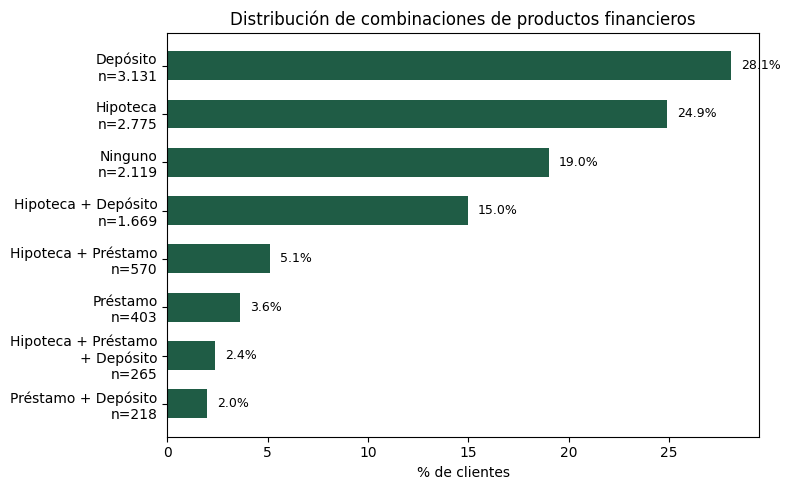

In [264]:
orden = df["productos_detalle"].value_counts().sort_values()
labels = [f"{textwrap.fill(str(i), width=20)}\nn={v:,}".replace(",", ".") for i, v in orden.items()]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, orden.values / len(df) * 100, color="#1F5C45", height=0.6)
for bar, val in zip(bars, orden.values / len(df) * 100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% de clientes")
ax.set_title("Distribución de combinaciones de productos financieros")
plt.tight_layout()
plt.show()

La mayor parte de los clientes dispone de uno o ningún producto financiero (8270 clientes = 75,4 %), mientras que el 24,6 % (2705 clientes) presenta un perfil multiproducto (dos o más productos). A partir de este subconjunto se analizarán las combinaciones de edad, nivel educativo y ocupación más frecuentes.

## Distribución entre multi no multi

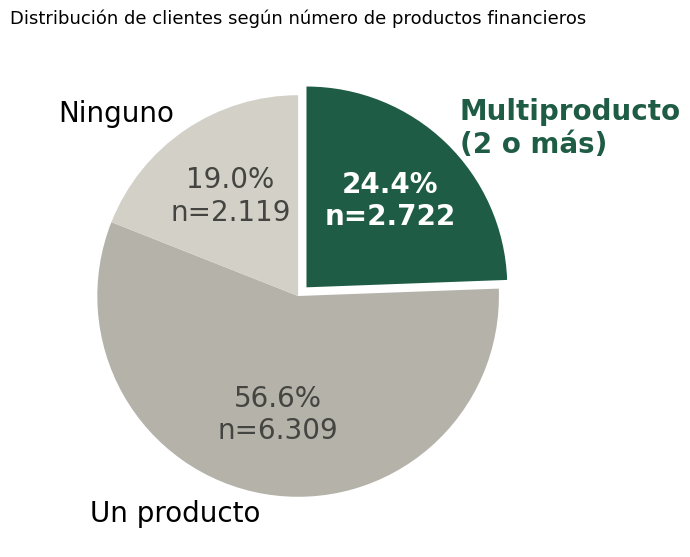

In [265]:
un_producto = (df["vinculacion"] == 1).sum()
multiproducto = (df["vinculacion"] >= 2).sum()
ninguno = (df["vinculacion"] == 0).sum()
total = len(df)

labels = ["Multiproducto\n(2 o más)", "Un producto", "Ninguno"]
values = [multiproducto, un_producto, ninguno]
colors = ["#1F5C45", "#B4B2A9", "#D3D1C7"]

fig, ax = plt.subplots(figsize=(6.5, 6))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%\nn={int(round(p/100*total)):,}".replace(",", "."),
    startangle=90,
    counterclock=False,
    explode=(0.06, 0, 0),
    textprops={"fontsize": 20}
)
autotexts[0].set_color("white")
autotexts[0].set_fontweight("bold")
autotexts[1].set_color("#444441")
autotexts[2].set_color("#444441")
texts[0].set_fontweight("bold")
texts[0].set_color("#1F5C45")

ax.set_title("Distribución de clientes según número de productos financieros", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

### Distribución de perfiles financieros

In [266]:
# df filtrado multicredito

df_multi = df[df["vinculacion"] >= 2].copy()

In [267]:
orden_edad = [
    "Young (18-25)",
    "Young Adult (26-35)",
    "Adult (36-50)",
    "Middle-Aged (51-65)",
    "Senior (65+)"
]

df_multi["age_group"] = pd.Categorical(
    df_multi["age_group"],
    categories=orden_edad,
    ordered=True
)

In [268]:
# función reutilizable variables categóricas

def tabla_perfil(df, var):
    porcentajes = (
        pd.crosstab(
            df[var],
            df["productos_detalle"],
            normalize="index"
        )
        .mul(100)
        .round(1)
    )

    n = pd.crosstab(
        df[var],
        columns="n"
    )

    tabla = n.join(porcentajes)
    tabla.columns.name = "productos_detalle (%)"

    return tabla

In [269]:
tabla_age = tabla_perfil(df_multi, "age_group")
tabla_age

productos_detalle (%),n,Hipoteca + Depósito,Hipoteca + Préstamo,Hipoteca + Préstamo + Depósito,Préstamo + Depósito
age_group,,,,,
Young (18-25),96,65.6,7.3,7.3,19.8
Young Adult (26-35),1108,63.0,19.6,9.9,7.5
Adult (36-50),1124,61.5,23.0,9.5,6.0
Middle-Aged (51-65),377,53.6,23.1,10.9,12.5
Senior (65+),17,88.2,0.0,0.0,11.8


En todos los grupos de edad de clientes multiproducto, la combinación Hipoteca + Depósito es la más frecuente. Los jóvenes (18–25 años) presentan la mayor proporción de Préstamo + Depósito (19,8 %), mientras que entre los clientes de 51 a 65 años aumenta ligeramente la presencia de perfiles con Hipoteca + Préstamo y con los tres productos contratados. Los resultados del grupo de mayores de 65 años deben interpretarse con cautela, ya que la muestra está formada por únicamente 17 clientes.

In [270]:
tabla_job = tabla_perfil(df_multi, "job_profile")
tabla_job

productos_detalle (%),n,Hipoteca + Depósito,Hipoteca + Préstamo,Hipoteca + Préstamo + Depósito,Préstamo + Depósito
job_profile,,,,,
Blue Collar,939,59.4,23.5,9.2,7.9
Retired,76,55.3,17.1,13.2,14.5
Self-Employed,189,52.9,27.5,11.1,8.5
Student,22,100.0,0.0,0.0,0.0
Unemployed,53,67.9,18.9,7.5,5.7
Unknown,2,0.0,0.0,100.0,0.0
White Collar,1441,63.2,19.0,9.9,7.9


La combinación Hipoteca + Depósito continúa siendo la más frecuente en la mayoría de los perfiles ocupacionales. Los clientes White Collar presentan una mayor concentración en esta combinación (63,5 %), mientras que entre los trabajadores por cuenta propia (Self-Employed) aumenta la presencia de Hipoteca + Préstamo (27,5 %), siendo el perfil con mayor proporción de esta combinación. Los resultados correspondientes a Student, Unemployed, Retired y, especialmente, Unknown deben interpretarse con cautela debido al reducido tamaño de sus muestras.

In [271]:
tabla_education = tabla_perfil(df_multi, "education_label")
tabla_education

productos_detalle (%),n,Hipoteca + Depósito,Hipoteca + Préstamo,Hipoteca + Préstamo + Depósito,Préstamo + Depósito
education_label,,,,,
Primary,328,59.1,25.6,9.5,5.8
Secondary,1535,57.5,23.4,10.0,9.1
Tertiary,786,68.6,14.8,9.4,7.3
Unknown,73,72.6,15.1,8.2,4.1


La combinación Hipoteca + Depósito es la más frecuente en todos los niveles educativos. Los clientes con estudios terciarios presentan la mayor concentración en esta combinación (68,9 %) y la menor presencia de Hipoteca + Préstamo (14,3 %), mientras que los niveles Primary y Secondary muestran una distribución más equilibrada entre las distintas combinaciones de productos. Los resultados correspondientes a la categoría Unknown deben interpretarse con cautela debido al reducido tamaño de la muestra (n = 73).

In [272]:
tabla_marital = tabla_perfil(df_multi, "marital")
tabla_marital

productos_detalle (%),n,Hipoteca + Depósito,Hipoteca + Préstamo,Hipoteca + Préstamo + Depósito,Préstamo + Depósito
marital,,,,,
divorced,353,61.5,19.8,9.1,9.6
married,1523,55.4,26.9,10.8,6.9
single,846,71.9,10.8,8.0,9.3


La combinación Hipoteca + Depósito sigue siendo la más frecuente en todos los estados civiles, aunque con diferencias notables. Los clientes solteros presentan la mayor concentración en esta combinación (72,0 %), mientras que entre los casados aumenta la presencia de perfiles con Hipoteca + Préstamo (26,3 %) y con los tres productos financieros contratados (10,9 %). Los clientes divorciados muestran un comportamiento intermedio entre ambos grupos.

#### Insight
Hipoteca + Depósito es la combinación predominante en todos los grupos demográficos analizados.
Las diferencias entre segmentos se explican sobre todo por la presencia de combinaciones que incluyen préstamo personal, especialmente Hipoteca + Préstamo.

In [273]:
# combo variables

combo = df_multi.groupby(['age_group','job_profile','education_label','marital'], observed=True).agg(
    n_clientes=('id','count')  
).reset_index()

combo['pct_su_multiproducto'] = (combo['n_clientes'] / combo['n_clientes'].sum() * 100).round(1)

combo_valide = combo[combo['n_clientes'] >= 30].sort_values('n_clientes', ascending=False)
combo_valide.head(15)

,age_group,job_profile,education_label,marital,n_clientes,pct_su_multiproducto
63,Adult (36-50),Blue Collar,Secondary,married,191,7.0
56,Young Adult (26-35),White Collar,Tertiary,single,184,6.8
95,Adult (36-50),White Collar,Secondary,married,169,6.2
22,Young Adult (26-35),Blue Collar,Secondary,married,169,6.2
98,Adult (36-50),White Collar,Tertiary,married,144,5.3
53,Young Adult (26-35),White Collar,Secondary,single,140,5.1
52,Young Adult (26-35),White Collar,Secondary,married,128,4.7
55,Young Adult (26-35),White Collar,Tertiary,married,121,4.4
23,Young Adult (26-35),Blue Collar,Secondary,single,109,4.0
60,Adult (36-50),Blue Collar,Primary,married,100,3.7


Al combinar las cuatro variables, destacan dos perfiles similares en frecuencia: adultos (36-50), Blue Collar, educación secundaria y casados (7,1 %); y jóvenes (26-35), White Collar, estudios terciarios y solteros (6,8 %). No hay un perfil dominante — la combinación más frecuente cubre solo el 7,1 % del total, lo que indica que el comportamiento multiproducto está bastante repartido entre segmentos. White Collar, Secondary y married/single son las categorías más recurrentes.

## Test estadístico

In [274]:
df['target_multi'] = (df['vinculacion'] >= 2).astype(int)   # transforma true/false en 1/0 (>=2)

def cramers_v(tab):
    chi2, p, dof, expected = chi2_contingency(tab)
    n = tab.sum().sum()
    r, k = tab.shape
    v = np.sqrt(chi2 / (n * (min(r-1, k-1))))   # formula
    return chi2, p, v

cat_cols = ['age_group','job_profile','education_label','marital']

for col in cat_cols:
    tab = pd.crosstab(df[col], df['target_multi'])
    chi2, p, v = cramers_v(tab)
    print(f"{col}: chi2={chi2:.1f}, p={p:.4f}, Cramér's V={v:.3f}")

age_group: chi2=170.4, p=0.0000, Cramér's V=0.124
job_profile: chi2=244.8, p=0.0000, Cramér's V=0.148
education_label: chi2=88.6, p=0.0000, Cramér's V=0.089
marital: chi2=6.8, p=0.0333, Cramér's V=0.025


- age_group p=0.0000 v=0.125 significativa, pero debil
- job_profile p=0.0000 v=0.151 significativa, la más fuerte
- education_label p=0.0000 v=0.089 significativa pero muy muy debil
- marital p=0.0429 v=0.024 significativa pero no relevante

El coeficiente de Cramér's V confirma que, aunque las cuatro asociaciones son estadísticamente significativas (p<0,05), su fuerza es débil en todos los casos (V<0,15). La variable job_profile es la que presenta mayor asociación con el comportamiento multiproducto (V=0,151), seguida de age_group (V=0,125), mientras que education_label (V=0,089) y especialmente marital (V=0,024) muestran una relación prácticamente irrelevante. Esto confirma que ninguna variable demográfica por sí sola explica de forma sólida quién se convierte en cliente multiproducto, resultado coherente con lo observado en el análisis por combinaciones: no existe un perfil dominante claro, sino un comportamiento bastante transversal entre segmentos.

#### Insight

Al combinar las cuatro variables demográficas, destacan dos perfiles similares en frecuencia dentro de los clientes multiproducto: adultos (36-50), Blue Collar, educación secundaria y casados (7,1 %); y jóvenes (26-35), White Collar, estudios terciarios y solteros (6,8 %). No hay un perfil dominante — la combinación más frecuente cubre solo el 7,1 % del total, lo que indica que el comportamiento multiproducto está bastante repartido entre segmentos.
Este resultado se confirma con el coeficiente de Cramér's V: aunque las cuatro variables muestran una asociación estadísticamente significativa con ser multiproducto (p<0,05), la fuerza de dicha asociación es débil en todos los casos (V<0,15). job_profile es la variable con mayor asociación (V=0,151), seguida de age_group (V=0,125), mientras que education_label y marital presentan una relación prácticamente irrelevante. En conjunto, ambos análisis apuntan a la misma conclusión: ninguna variable demográfica, ni sus combinaciones, explica de forma sólida quién se convierte en cliente multiproducto — se trata de un comportamiento transversal, sin un perfil claramente diferenciado.

In [275]:
# se repite con 3 variables (marital no significativa)

combo_3var = df_multi.groupby(['age_group','job_profile','education_label'], observed=False).agg(
    n_clientes=('id','count')
).reset_index()

combo_3var['pct_su_multiproducto'] = (combo_3var['n_clientes'] / combo_3var['n_clientes'].sum() * 100).round(1)

combo_3var_valide = combo_3var[combo_3var['n_clientes'] >= 30].sort_values('n_clientes', ascending=False)
combo_3var_valide.head(15)

,age_group,job_profile,education_label,n_clientes,pct_su_multiproducto
54,Young Adult (26-35),White Collar,Tertiary,326,12.0
81,Adult (36-50),White Collar,Secondary,310,11.4
53,Young Adult (26-35),White Collar,Secondary,297,10.9
29,Young Adult (26-35),Blue Collar,Secondary,296,10.9
57,Adult (36-50),Blue Collar,Secondary,266,9.8
82,Adult (36-50),White Collar,Tertiary,240,8.8
56,Adult (36-50),Blue Collar,Primary,137,5.0
109,Middle-Aged (51-65),White Collar,Secondary,99,3.6
28,Young Adult (26-35),Blue Collar,Primary,63,2.3
110,Middle-Aged (51-65),White Collar,Tertiary,63,2.3


In [276]:
# top 5 con df noactualizado

print("Top 5 combo, 4 variables:", combo_valide.head(5)['n_clientes'].sum() / 2705 * 100)
print("Top 5 combo, 3 variables:", combo_3var_valide.head(5)['n_clientes'].sum() / 2705 * 100)

Top 5 combo, 4 variables: 31.68207024029575
Top 5 combo, 3 variables: 55.26802218114602


In [277]:
# prueba 2 variables, no

combo_2var = df_multi.groupby(['age_group','job_profile'], observed=False).agg(
    n_clientes=('id','count')
).reset_index()
combo_2var['pct'] = (combo_2var['n_clientes'] / combo_2var['n_clientes'].sum() * 100).round(1)
combo_2var_valide = combo_2var[combo_2var['n_clientes'] >= 30].sort_values('n_clientes', ascending=False)
combo_2var_valide.head(10)

print("Top 5 combo, 2 variabili:", combo_2var_valide.head(5)['n_clientes'].sum() / 2705 * 100)

Top 5 combo, 2 variabili: 81.0720887245841


Al eliminar marital del análisis conjunto —variable con una asociación prácticamente nula (Cramér's V=0,024)— la concentración de los perfiles mejora notablemente: las 5 combinaciones más frecuentes de edad, ocupación y educación pasan al 55,0 % de los clientes multiproducto, frente al 31,5 % con las cuatro variables originales. El perfil más destacado es el de jóvenes adultos (26-35 años), White Collar, con estudios terciarios (12,0 % del total), seguido de cerca por adultos (36-50 años), White Collar, con educación secundaria (11,3 %).
Este resultado, junto con el análisis de Cramér's V, confirma que job_profile y age_group son las variables demográficas más relevantes para caracterizar al cliente multiproducto, mientras que marital aporta poca información adicional. Se probó también eliminar education_label, dejando solo edad y ocupación: en ese caso las 5 combinaciones principales cubren el 80,6 % del total. Sin embargo, este salto se debe en parte al efecto de reducir el número de combinaciones posibles (de unas 70 a solo 30). Por este motivo, se mantiene el modelo de tres variables (edad, ocupación y educación) como resultado principal, ya que ofrece el mejor equilibrio entre concentración del patrón y nivel de detalle útil para el negocio.
Cabe señalar que estos resultados son provisionales(dataset no actualizado)

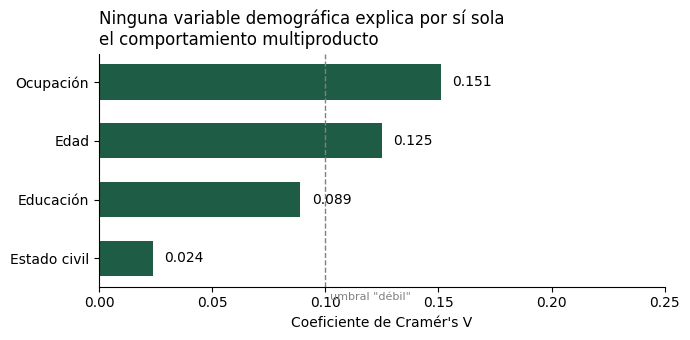

In [278]:
# visualización Cramer's v

valores = {
    'job_profile': 0.151,
    'age_group': 0.125,
    'education_label': 0.089,
    'marital': 0.024
}
etiquetas_es = {
    'job_profile': 'Ocupación',
    'age_group': 'Edad',
    'education_label': 'Educación',
    'marital': 'Estado civil'
}

serie = pd.Series(valores).rename(index=etiquetas_es).sort_values()

fig, ax = plt.subplots(figsize=(7,3.5))
bars = ax.barh(serie.index, serie.values, color='#1F5C45', height=0.6)

for bar, val in zip(bars, serie.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=10)

ax.axvline(0.10, color='gray', linestyle='--', linewidth=1)
ax.text(0.102, -0.7, 'umbral "débil"', fontsize=8, color='gray')

ax.set_xlabel("Coeficiente de Cramér's V")
ax.set_title("Ninguna variable demográfica explica por sí sola\nel comportamiento multiproducto",
             fontsize=12, loc='left')
ax.set_xlim(0, 0.25)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

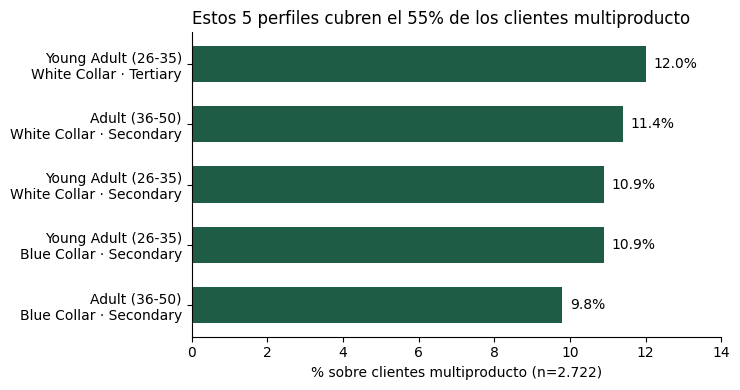

In [279]:
# top 5 perfiles (3 variables)

top5 = combo_3var_valide.head(5).copy()
top5['perfil'] = (
    top5['age_group'].astype(str) + "\n" +
    top5['job_profile'] + " · " + top5['education_label']
)
top5 = top5.sort_values('pct_su_multiproducto')

fig, ax = plt.subplots(figsize=(7.5,4))
bars = ax.barh(top5['perfil'], top5['pct_su_multiproducto'], color='#1F5C45', height=0.6)

for bar, val in zip(bars, top5['pct_su_multiproducto']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10)

pct_top5 = top5['pct_su_multiproducto'].sum()
n_multiproducto = len(df_multi)
ax.set_xlabel(f"% sobre clientes multiproducto (n={n_multiproducto:,})".replace(",", "."))
ax.set_title(f"Estos 5 perfiles cubren el {pct_top5:.0f}% de los clientes multiproducto",
             fontsize=12, loc='left')
ax.set_xlim(0, 14)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

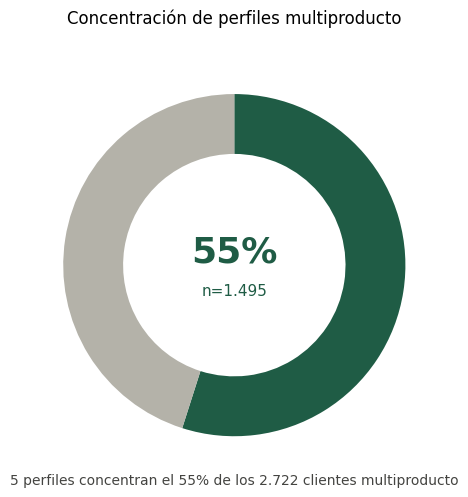

In [280]:
# Donut: concentración de los 5 perfiles principales sobre el total multiproducto
top5_n = combo_3var_valide.head(5)['n_clientes'].sum()
total_multi = len(df_multi)
pct_top5 = top5_n / total_multi * 100

fig, ax = plt.subplots(figsize=(5, 5))
wedges, _ = ax.pie(
    [pct_top5, 100 - pct_top5],
    colors=["#1F5C45", "#B4B2A9"],
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.35)
)
ax.text(0, 0.08, f"{pct_top5:.0f}%", ha="center", va="center", fontsize=26, fontweight="bold", color="#1F5C45")
ax.text(0, -0.15, f"n={top5_n:,}".replace(",", "."), ha="center", va="center", fontsize=11, color="#1F5C45")
ax.set_title("Concentración de perfiles multiproducto", fontsize=12, pad=20)
plt.figtext(0.5, 0.02, f"5 perfiles concentran el {pct_top5:.0f}% de los {total_multi:,} clientes multiproducto".replace(",", "."),
            ha="center", fontsize=10, color="#444441")
plt.tight_layout()
plt.show()

In [281]:
# Perfil núcleo: rango de valores presentes en el top 5 de combo_3var_valide
top5 = combo_3var_valide.head(5)

edades = top5['age_group'].unique().tolist()
ocupaciones = top5['job_profile'].unique().tolist()
formaciones = top5['education_label'].unique().tolist()

# % de "Hipoteca + Depósito" dentro de cada uno de los 5 perfiles
pcts_dominante = []
for _, row in top5.iterrows():
    subset = df_multi[
        (df_multi['age_group']==row['age_group']) &
        (df_multi['job_profile']==row['job_profile']) &
        (df_multi['education_label']==row['education_label'])
    ]
    pct = (subset['productos_detalle']=='Hipoteca + Depósito').mean()*100
    pcts_dominante.append(pct)

perfil_nucleo = {
    "Edad": " / ".join(edades),
    "Formación": " / ".join(formaciones),
    "Ocupación": " / ".join(ocupaciones),
    "Producto dominante": f"Hipoteca + Depósito ({min(pcts_dominante):.0f}%-{max(pcts_dominante):.0f}%)"
}

for k, v in perfil_nucleo.items():
    print(f"{k}: {v}")

Edad: Young Adult (26-35) / Adult (36-50)
Formación: Tertiary / Secondary
Ocupación: White Collar / Blue Collar
Producto dominante: Hipoteca + Depósito (57%-73%)


## Árbol de decisiones (exploratorio — pendiente de revisión con dataset ampliado)

Nota: este árbol responde a una pregunta distinta de la formulada en el reto ("combinaciones más comunes"). Aquí se explora qué perfiles demográficos muestran mayor o menor *propensión* a ser multiproducto respecto a la media — información complementaria para la personalización de ofertas, no la respuesta principal a la pregunta de negocio (que se responde en `combo_3var_valide`, más arriba).

### Preparación de los datos asignando orden de las categorías


In [282]:
# Árbol de decisión: variables de entrada

# Reutilizamos el orden de edad ya definido en orden_edad (cell 99)
edu_order = ["Primary", "Secondary", "Tertiary", "Unknown"]

age_encoder = OrdinalEncoder(categories=[orden_edad])
df["age_encoded"] = age_encoder.fit_transform(df[["age_group"]])

edu_encoder = OrdinalEncoder(categories=[edu_order])
df["edu_encoded"] = edu_encoder.fit_transform(df[["education_label"]])

# job_profile y marital son nominales -> one-hot (igual que hicimos con age/education aquí)
nominal_dummies = pd.get_dummies(df[["job_profile", "marital"]], prefix=["job", "marital"])

X = pd.concat([df[["age_encoded", "edu_encoded"]], nominal_dummies], axis=1)
feature_names = list(X.columns)
y = df["target_multi"]

### Entrenamiento

In [283]:
tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    class_weight="balanced",  # target_multi está desbalanceado (24,6% vs 75,4%, cell 96)
    random_state=42
)
tree.fit(X, y)

print(export_text(tree, feature_names=feature_names, show_weights=True))

|--- age_encoded <= 2.50
|   |--- job_Student <= 0.50
|   |   |--- edu_encoded <= 1.50
|   |   |   |--- job_Unemployed <= 0.50
|   |   |   |   |--- weights: [2230.53, 3172.55] class: 1
|   |   |   |--- job_Unemployed >  0.50
|   |   |   |   |--- weights: [105.18, 79.88] class: 0
|   |   |--- edu_encoded >  1.50
|   |   |   |--- job_Unemployed <= 0.50
|   |   |   |   |--- weights: [1596.16, 1454.17] class: 0
|   |   |   |--- job_Unemployed >  0.50
|   |   |   |   |--- weights: [50.27, 16.39] class: 0
|   |--- job_Student >  0.50
|   |   |--- age_encoded <= 0.50
|   |   |   |--- edu_encoded <= 1.50
|   |   |   |   |--- weights: [82.69, 6.14] class: 0
|   |   |   |--- edu_encoded >  1.50
|   |   |   |   |--- weights: [35.06, 4.10] class: 0
|   |   |--- age_encoded >  0.50
|   |   |   |--- edu_encoded <= 1.50
|   |   |   |   |--- weights: [47.63, 18.43] class: 0
|   |   |   |--- edu_encoded >  1.50
|   |   |   |   |--- weights: [57.55, 16.39] class: 0
|--- age_encoded >  2.50
|   |--- age_

In [284]:
df["leaf"] = tree.apply(X)
resumen = df.groupby("leaf").agg(n=("target_multi", "size"), n_multi=("target_multi", "sum"))
resumen["pct_multiproducto"] = (resumen["n_multi"] / resumen["n"] * 100).round(1)

def walk(node_id, path, leaves):
    t = tree.tree_
    if t.children_left[node_id] == _tree.TREE_LEAF:
        leaves[node_id] = path
        return
    feat = feature_names[t.feature[node_id]]
    thr = t.threshold[node_id]
    walk(t.children_left[node_id], path + [f"{feat} <= {thr:.2f}"], leaves)
    walk(t.children_right[node_id], path + [f"{feat} > {thr:.2f}"], leaves)

leaves = {}
walk(0, [], leaves)

resumen_valide = resumen[resumen["n"] >= 50].sort_values("pct_multiproducto", ascending=False)
for leaf_id, row in resumen_valide.iterrows():
    print(f"n={int(row['n'])}, multiproducto={row['pct_multiproducto']}%  |  {' AND '.join(leaves[leaf_id])}")

n=4921, multiproducto=31.5%  |  age_encoded <= 2.50 AND job_Student <= 0.50 AND edu_encoded <= 1.50 AND job_Unemployed <= 0.50
n=414, multiproducto=24.4%  |  age_encoded > 2.50 AND age_encoded <= 3.50 AND marital_married <= 0.50 AND edu_encoded > 0.50
n=3123, multiproducto=22.7%  |  age_encoded <= 2.50 AND job_Student <= 0.50 AND edu_encoded > 1.50 AND job_Unemployed <= 0.50
n=198, multiproducto=19.7%  |  age_encoded <= 2.50 AND job_Student <= 0.50 AND edu_encoded <= 1.50 AND job_Unemployed > 0.50
n=1260, multiproducto=17.7%  |  age_encoded > 2.50 AND age_encoded <= 3.50 AND marital_married > 0.50 AND job_Retired <= 0.50
n=88, multiproducto=15.9%  |  age_encoded > 2.50 AND age_encoded <= 3.50 AND marital_married <= 0.50 AND edu_encoded <= 0.50
n=306, multiproducto=12.7%  |  age_encoded > 2.50 AND age_encoded <= 3.50 AND marital_married > 0.50 AND job_Retired > 0.50
n=81, multiproducto=11.1%  |  age_encoded <= 2.50 AND job_Student > 0.50 AND age_encoded > 0.50 AND edu_encoded <= 1.50
n=

**Validación cruzada**: un árbol de decisión de solo dos niveles de profundidad, entrenado de forma independiente sobre las mismas variables demográficas, confirma este perfil núcleo: el 71% de los clientes multiproducto tiene 50 años o menos y no es estudiante, alcanzando una tasa de multiproducto del 28,6% frente al 24,4% global — validando de forma independiente el hallazgo descriptivo anterior.

#### Insight — Árbol de decisión (exploratorio)

Dado que ninguna variable demográfica individual mostró una asociación relevante con `target_multi` (Cramér's V máximo de 0,151 para `job_profile`), se aplicó un árbol de decisión para explorar si alguna combinación de variables mostraba una propensión especialmente alta o baja a ser multiproducto.

El perfil con mayor impacto real en volumen (no solo en porcentaje) es "≤50 años, formación Primary/Secondary" (n=4.662), con 341 clientes multiproducto más de los esperados por la media. El resto de perfiles identificados muestran déficits moderados, sin aportar volumen adicional relevante.

Nota adicional: la fuerza de `job_profile` en Cramér's V se debe casi por completo a sus categorías minoritarias (estudiantes, desempleados, jubilados) — las categorías mayoritarias (White Collar, Blue Collar, 84% de los clientes) no diferencian la propensión a multiproducto una vez controlado por edad y educación.

Un árbol de decisión de solo dos niveles confirma el hallazgo: el 71% de los clientes multiproducto tiene menos de 50 años y no es estudiante, alcanzando una tasa de multiproducto del 28,6% frente al 24,4% global.

## Propuestas de negocio

### potencial nuevos clientes

In [286]:
# Grupo con potencial de conversión: clientes con 1 producto, según la tasa de
# multiproducto de su perfil demográfico (basado en el árbol ya entrenado)

base_rate = df["target_multi"].mean() * 100

un_producto = df[df["vinculacion"] == 1].copy()
un_producto = un_producto.merge(
    resumen[["pct_multiproducto", "n"]].rename(columns={"pct_multiproducto": "pct_peer", "n": "n_peer_total"}),
    left_on="leaf", right_index=True
)

def categoria_potencial(pct_peer):
    if pct_peer >= 30:
        return "Alto potencial"
    elif pct_peer >= base_rate:
        return "Potencial medio"
    else:
        return "Bajo potencial"

un_producto_validos = un_producto[un_producto["n_peer_total"] >= 100].copy()
un_producto_validos["potencial_conversion"] = un_producto_validos["pct_peer"].apply(categoria_potencial)

grupos_potenciales = (
    un_producto_validos.groupby("potencial_conversion")
    .agg(n_clientes=("target_multi", "size"), pct_peer_medio=("pct_peer", "mean"))
    .round(1)
    .sort_values("pct_peer_medio", ascending=False)
)

print(grupos_potenciales)

                      n_clientes  pct_peer_medio
potencial_conversion                            
Alto potencial              2570            31.5
Bajo potencial              3428            19.0


### Call to action

1. Diseñar una campaña de onboarding específica para el 19,0% de clientes sin ningún producto, como paso previo indispensable antes de cualquier estrategia de cross-selling.

2. Priorizar el cross-selling dentro del 56,6% de clientes con un solo producto, ofreciendo el paquete Hipoteca + Depósito como producto ancla —validado como la combinación dominante en todos los perfiles—, y contactando primero a los 2.570 clientes de "alto potencial" (perfil demográfico con una tasa de multiproducto del 31,5% entre sus iguales), dejando en segundo plano a los 3.428 de "bajo potencial" (19,0%).

3. No personalizar el producto ofrecido según edad, ocupación o formación: ninguna variable demográfica explica por sí sola el comportamiento multiproducto (Cramér's V < 0,16 en las cuatro) y la combinación dominante es la misma en todos los grupos. El perfil demográfico combinado —no cada variable por separado— sirve únicamente para ordenar la prioridad de contacto, no para diferenciar la oferta.

In [ ]:
# ============================================
# BASELINE DE REFERENCIA (semana anterior, 10.975 registros)
# ============================================
baseline = {
    "total_registros": 10975,
    "pct_multiproducto": 24.6,
    "productos_detalle_pct": {
        "Depósito": 28.5,
        "Hipoteca": 24.5,
        "Ninguno": 18.7,
        "Hipoteca + Depósito": 15.2,
        "Hipoteca + Préstamo": 5.0,
        "Préstamo": 3.6,
        "Hipoteca + Préstamo + Depósito": 2.4,
        "Préstamo + Depósito": 2.0
    },
    "cramers_v": {
        "Ocupación": 0.151,
        "Edad": 0.125,
        "Educación": 0.089,
        "Estado civil": 0.024
    },
    "top5_combo3var": [
        ("Young Adult (26-35), White Collar, Tertiary", 12.0),
        ("Adult (36-50), White Collar, Secondary", 11.3),
        ("Young Adult (26-35), White Collar, Secondary", 10.9),
        ("Young Adult (26-35), Blue Collar, Secondary", 10.8),
        ("Adult (36-50), Blue Collar, Secondary", 9.8)
    ],
    "top5_pct_acumulado": 55.0
}

In [ ]:
# ============================================
# COMPARACIÓN AUTOMÁTICA con el dataset nuevo
# ============================================
print("=== Tamaño del dataset ===")
print(f"{baseline['total_registros']:,} -> {len(df):,}".replace(",", "."))
print()

print("=== % Multiproducto ===")
pct_multi_actual = round(df["target_multi"].mean()*100, 1)
print(f"{baseline['pct_multiproducto']}% -> {pct_multi_actual}%")
print()

print("=== Distribución de productos_detalle ===")
actual_dist = (df["productos_detalle"].value_counts(normalize=True)*100).round(1).to_dict()
for k, v_old in baseline["productos_detalle_pct"].items():
    v_new = actual_dist.get(k, "N/D")
    print(f"{k}: {v_old}% -> {v_new}%")
print()

print("=== Cramér's V por variable (recalcular con tu función existente) ===")
for var, v_old in baseline["cramers_v"].items():
    print(f"{var}: {v_old} -> (recalcular)")
print()

print("=== Top 5 combo_3var (referencia semana anterior) ===")
for label, pct_old in baseline["top5_combo3var"]:
    print(f"{label}: {pct_old}% (semana anterior)")
print(f"Acumulado: {baseline['top5_pct_acumulado']}%")
print()
print(">> Ejecutar combo_3var_valide.head(5) con el df nuevo y comparar visualmente")

=== Tamaño del dataset ===
10.975 -> 11.150

=== % Multiproducto ===
24.6% -> 24.4%

=== Distribución de productos_detalle ===
Depósito: 28.5% -> 28.1%
Hipoteca: 24.5% -> 24.9%
Ninguno: 18.7% -> 19.0%
Hipoteca + Depósito: 15.2% -> 15.0%
Hipoteca + Préstamo: 5.0% -> 5.1%
Préstamo: 3.6% -> 3.6%
Hipoteca + Préstamo + Depósito: 2.4% -> 2.4%
Préstamo + Depósito: 2.0% -> 2.0%

=== Cramér's V por variable (recalcular con tu función existente) ===
Ocupación: 0.151 -> (recalcular)
Edad: 0.125 -> (recalcular)
Educación: 0.089 -> (recalcular)
Estado civil: 0.024 -> (recalcular)

=== Top 5 combo_3var (referencia semana anterior) ===
Young Adult (26-35), White Collar, Tertiary: 12.0% (semana anterior)
Adult (36-50), White Collar, Secondary: 11.3% (semana anterior)
Young Adult (26-35), White Collar, Secondary: 10.9% (semana anterior)
Young Adult (26-35), Blue Collar, Secondary: 10.8% (semana anterior)
Adult (36-50), Blue Collar, Secondary: 9.8% (semana anterior)
Acumulado: 55.0%

>> Ejecutar combo_3